# Regression

| Key              | Value                                                                                                                                                                                                                                                                                                 |
|:-----------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Course Codes** | BBT 4106 and BFS 4102                                                                                                                                                                                                                                                                                 |
| **Course Names** | BBT 4206: Business Intelligence I (Week 11-13 of 13) and<br/>BFS 4102: Advanced Business Data Analytics (Week 1-3 of 13)                                                                                                                                                                              |
| **Semester**     | August to November 2026                                                                                                                                                                                                                                                                               |
| **Lecturer**     | Allan Omondi                                                                                                                                                                                                                                                                                          |
| **Contact**      | aomondi@strathmore.edu                                                                                                                                                                                                                                                                                |
| **Note**         | The lecture contains both theory and practice.<br/>This notebook forms part of the practice.<br/>It is intended for educational purposes only.<br/>Recommended citation: [BibTex](https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/RecommendedCitation.bib) |

**Business context**: "Jenga Biashara" is a *fictional* venture capital firm
focused on Kenyan SMEs. Its advisory team needs a defensible estimate of how
much monthly revenue a given SME is actually generating before the firm extends
working capital facilities or recommends an SME for an investment program.
Many applicant businesses, especially sole proprietorships and informal
enterprises, do not keep audited financial statements. However, they at least
have a set of observable and verifiable signals, e.g., how long they have
operated, whether they have taken any loans, how satisfied their customers
are, etc.

Jenga Biashara's data engineering team has curated these signals and added
macroeconomic indicators (specifically interest rate and inflation) into a
single dataset spanning six sectors and six counties. You are requried to train
a model that the advisory team can use to predict `monthly_revenue_kes` from
these observable features. This model can subsequently be used to flag
businesses whose self-reported revenue looks inconsistent with their operating
profile.

**Dataset**: The dataset is *synthetic*. However, effort has been made to make
it realistic by:
- Having revenue data skewed to the right, i.e., most enterprises cluster at
moderate revenue, and a handful of enterprises pull the distribution's tail.
- Having features that are highly correlated (near duplicates of each other).
This can happen when two or more departments record similar data under
different names. Then the data pipeline picks both departments' data.
- Having features that are randomly missing data and in other cases, have no
data at all for an entire category (sector).

**File**: `sme_revenue_kenya.csv` | **Rows**: 1,500 | **Target**: `monthly_revenue_kes`

| Feature                       | Type                                           | Description                                                                                                                                                                                                                                                               |
|-------------------------------|------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `business_id`                 | Identifier (discrete, ratio scale)             | Unique reference number for each business. Not a predictor - excluded from modeling in Stage 4.                                                                                                                                                                           |
| `sector`                      | Categorical (nominal)                          | Primary industry of the business: `Retail`, `Hospitality`, `Agriculture`, `Manufacturing`, `Services`, or `Technology`.                                                                                                                                                   |
| `county`                      | Categorical (nominal)                          | County (or county grouping) where the business operates: `Nairobi`, `Mombasa`, `Kisumu`, `Nakuru`, `Eldoret`, or `Other`.                                                                                                                                                 |
| `quarter`                     | Categorical (nominal)                          | Calendar quarter of the observation (`Q1`-`Q4`). Determines the prevailing `inflation_rate_pct` for that observation.                                                                                                                                                     |
| `business_age_years`          | Numeric (continuous, ratio scale)              | Number of years the business has been operating, including partial years.                                                                                                                                                                                                 |
| `num_employees`               | Numeric (discrete, ratio scale)                | Total number of people employed by the business, including the owner if actively working in it.                                                                                                                                                                           |
| `payroll_cost_kes`            | Numeric (continuous, ratio scale)              | Total monthly payroll expenditure in KES. Correlated with `num_employees` by construction - this pairing is used in the lab to illustrate multicollinearity detection (correlation filtering, VIF).                                                                       |
| `owner_education_level`       | Categorical (ordinal)                          | Highest education level completed by the business owner: `Primary` < `Secondary` < `Certificate` < `Diploma` < `Bachelor's` < `Master's` < `Doctorate`.                                                                                                                   |
| `monthly_marketing_spend_kes` | Numeric (continuous, ratio scale)              | Total monthly spend on marketing activities, in KES.                                                                                                                                                                                                                      |
| `advertising_budget_kes`      | Numeric (continuous, ratio scale)              | A separately reported advertising budget figure, closely tracking `monthly_marketing_spend_kes`. Included as a near-duplicate predictor pair for feature-selection practice, reflecting how two overlapping budget lines are often logged separately in real bookkeeping. |
| `avg_daily_foot_traffic`      | Numeric (continuous, ratio scale)              | Average number of in-person customer visits per day. **Missing for all `Technology`-sector businesses**, because fully online businesses do not have a physical storefront to measure. This is structural missingness, not missing-at-random.                             |
| `online_presence_score`       | Numeric (continuous, ratio scale: 0-100)       | A composite score reflecting the business's digital visibility (website quality, social media activity, online reviews).                                                                                                                                                  |
| `loan_amount_kes`             | Numeric (continuous, ratio scale)              | Outstanding loan amount held by the business, in KES. Zero for businesses with no active loan.                                                                                                                                                                            |
| `interest_rate_pct`           | Numeric (continuous, ratio scale)              | Interest rate, in percent, applied to the business's loan (where applicable).                                                                                                                                                                                             |
| `inflation_rate_pct`          | Numeric (continuous, ratio scale)              | Macroeconomic inflation rate, in percent, prevailing in the business's `quarter`. This value is shared across all businesses observed in the same quarter, with small measurement noise added.                                                                            |
| `competitor_density`          | Numeric (continuous, ratio scale)              | Number of directly competing businesses operating in the same immediate area.                                                                                                                                                                                             |
| `customer_satisfaction_score` | Numeric (continuous, ratio scale: 1-5)         | Average customer satisfaction rating from post-purchase surveys. **Missing at random** for roughly 5% of businesses (non-responsive customers).                                                                                                                           |
| `monthly_revenue_kes`         | Numeric (continuous, ratio scale) - **Target** | Total business revenue for the month, in KES. Right-skewed, with a small number of injected high-revenue outliers representing unusually large, well-established enterprises.                                                                                             |

**Notes on Synthetic Dataset:**
- **`payroll_cost_kes` / `num_employees`** and **`advertising_budget_kes` / `monthly_marketing_spend_kes`**
  exist to make multicollinearity a concrete, visible problem, not an
  abstract warning.
- **`avg_daily_foot_traffic`** exists to distinguish *structural* missingness (a Technology
  business genuinely has no foot traffic to measure) from *random* missingness
  (`customer_satisfaction_score`, where a client simply did not respond to a survey). These
  two situations require different data imputation reasoning, and the dataset requires you to
  tell them apart rather than apply one data imputation technique everywhere.
- **`monthly_revenue_kes`**'s right skew is what makes the Box-Cox / Yeo-Johnson stage
  a genuine modeling decision rather than a routine checkbox.

**Remote Environments:**

Do your best to set up your local environment as guided during the lab, however, if you have challenges setting it up, then you can use the following remote environments temporarily for the lab:<br/>

[![Colab](https://img.shields.io/badge/Open-Colab-orange?logo=googlecolab)](
https://colab.research.google.com/github/course-files/RegressionAndClassification/blob/main/1_regression.ipynb) (preferred option)

[![Codespaces](https://img.shields.io/badge/Open-Codespaces-blue?logo=github)](
https://github.com/codespaces/new/course-files/RegressionAndClassification) (alternative)

## Install Dependencies and Import Required Libraries

Install the `ipykernel` package (required for Jupyter notebook) then confirm the following:
1. Where the Python interpreter that will be used to execute code is located
2. The version of the Python interpreter

Then install all the packages into the Jupyter notebook's virtual environment before importing them.

In [1]:
# Install `ipykernel` for Jupyter notebook
%pip install ipykernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Confirm where the Python interpreter is located
import sys
print(sys.executable)
# print(sys.version)

C:\Users\aomondi\Documents\GitHub\Teaching\RegressionAndClassification\.venv\Scripts\python.exe


In [3]:
# Confirm the version of the Python interpreter
!{sys.executable} --version

Python 3.12.10


### Set the Environment Variables

In [4]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
import os
from dotenv import load_dotenv

# This loads .env from the current (or parent) directory if present
# `override=True` ensures that the values set in the .env file take precedence
# over any existing environment variables set in the Operating System
load_dotenv(override=True)

def resolve_environment():
    if os.environ.get("ENVIRONMENT"):
        return os.environ["ENVIRONMENT"].upper()

    # Automatic detection if running in Google Colab
    if "google.colab" in sys.modules:
        return "COLAB"

    # Defaults to a 'DEV' environment if it is not set
    return "DEV"

ENV_SETUP = resolve_environment()

VALID_ENVIRONMENTS = {"PROD", "STAGING", "TESTING", "COLAB", "DEV"}

if ENV_SETUP not in VALID_ENVIRONMENTS:
    print(f"Warning: Invalid ENVIRONMENT '{ENV_SETUP}'. Defaulting to 'DEV'.")
    ENV_SETUP = "DEV"

print(f"Dependencies will be installed for a '{ENV_SETUP}' environment.")

Dependencies will be installed for a 'DEV' environment.


In [6]:
import sys
import subprocess

def silent_pip_install(args):
    """
    Used to run a command quietly and
    only shows an error if something went wrong.
    :param args: Array of arguments that form the command.
    :return:
    """

    # `sys.executable` is added to ensure you are installing into the virtual environment
    cmd = [sys.executable, "-m", "pip", *args]
    # `subprocess.run` is used to execute an external command
    # `stdout=subprocess.PIPE` captures normal output into result.stdout
    # `stderr=subprocess.PIPE` captures error output into result.stderr
    # `text=True` decodes output as strings (str) instead of bytes, so you can print/read it directly.
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    # `result.returncode` is the process exit status. 0 means success.
    if result.returncode != 0:
        print(result.stderr)

if ENV_SETUP == "PROD":
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/prod.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"STAGING"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/dev.txt",
        "-c", "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/constraints.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"TESTING"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/dev.txt",
        "-c", "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/constraints.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"COLAB"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/colab.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"DEV"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/dev.txt",
        "-c", "https://raw.githubusercontent.com/course-files/RegressionAndClassification//refs/heads/main/requirements/constraints.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

Completed installation of environment dependencies for 'DEV'.


In [7]:
# For file and system operations
import urllib.request
import os

# For suppressing warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("The environment ready.")

The environment ready.


## Load the Data

We load the synthetic SME dataset and confirm its shape (number of
rows/observations and number of columns/features), data types, and target
variable before proceeding further. This enables us to understand the structure
of the dataset and identify any potential issues that may need to be addressed
before training the model.

In [9]:
dataset_path = './data/sme_revenue_kenya.csv'
url = 'https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/data/sme_revenue_kenya.csv'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    if not os.path.exists('./data'):
        os.makedirs('./data')
    urllib.request.urlretrieve(url, dataset_path)
    print("✅ Dataset downloaded")
else:
    print("✅ Dataset already exists locally")

use_cols = ['business_id', 'sector', 'county', 'quarter', 'business_age_years', 'num_employees', 'payroll_cost_kes', 'owner_education_level', 'monthly_marketing_spend_kes', 'advertising_budget_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'loan_amount_kes', 'interest_rate_pct', 'inflation_rate_pct', 'competitor_density', 'customer_satisfaction_score', 'monthly_revenue_kes']
sme_data = pd.read_csv(dataset_path, usecols=use_cols, encoding='utf-8', nrows=200000)

✅ Dataset already exists locally


In [10]:
print(f"Shape: {sme_data.shape[0]} rows, {sme_data.shape[1]} columns")
sme_data.head()

Shape: 1500 rows, 18 columns


,business_id,sector,county,quarter,business_age_years,num_employees,payroll_cost_kes,owner_education_level,monthly_marketing_spend_kes,advertising_budget_kes,avg_daily_foot_traffic,online_presence_score,loan_amount_kes,interest_rate_pct,inflation_rate_pct,competitor_density,customer_satisfaction_score,monthly_revenue_kes
0,1,Services,Nakuru,Q3,10.7,8,170390.0,Bachelors,12268.0,11859.0,34.9,57.3,0.0,8.99,6.55,5,3.4,4581022.0
1,2,Hospitality,Other,Q4,4.7,8,180398.0,Diploma,59536.0,55943.0,25.7,60.8,149486.0,17.77,7.37,8,4.2,1863102.0
2,3,Services,Mombasa,Q3,12.8,10,276286.0,Secondary,16910.0,17789.0,54.2,59.8,200664.0,19.55,6.26,5,4.0,2739637.0
3,4,Manufacturing,Mombasa,Q3,3.0,16,336298.0,Diploma,28642.0,28684.0,64.4,33.3,0.0,16.77,6.50,3,2.9,3321994.0
4,5,Retail,Other,Q2,7.4,9,254711.0,Secondary,33122.0,40272.0,92.9,58.4,0.0,10.03,6.93,3,3.8,1430695.0


### Identify the Target Variable

In [11]:
# Target variable identification
TARGET = "monthly_revenue_kes"

# `business_id` is an identifier, not a predictive feature. We will drop it
# but keep it in the raw (original) DataFrame in case we need to trace
# a specific row later.
print(f"Target variable: {TARGET}")
print(f"Number of features (excluding IDs and the target): {sme_data.shape[1] - 2}")

Target variable: monthly_revenue_kes
Number of features (excluding IDs and the target): 16


## Initial Exploratory Data Analysis

The initial Exploratory Data Analysis (EDA) is composed of:

### Measures of Frequency
  - Count (number of observations [rows], number of features [columns])
  - Percent (for categorical features)

### Measures of Central Tendency
  - Mean
  - Median
  - Mode

### Measures of Relationship
  - Correlation (both Spearman and Pearson)

### Measures of Distribution
  - Minimum value
  - Lower quartile (`Q1`)
  - Middle quartile (`Q2`) = Median
  - Upper quartile (`Q3`)
  - Maximum value
  - Variance
  - Standard deviation
  - Skewness
  - Kurtosis
  - Interquartile range (IQR) = `Q3 - Q1`
  - Lower fence
  - Upper fence

Reference image:
![BoxCox](https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/assets/images/BoxPlot.jpg)

#### Interpretation of Kurtosis (Fisher kurtosis)

Kurtosis describes "tail heaviness" relative to a normal distribution.

Interpretation of kurtosis (Fisher kurtosis):
1. Kurtosis < 0: platykurtic (lighter tails than normal)
2. Kurtosis near 0: mesokurtic (similar tail weight to normal)
3. Kurtosis > 0: leptokurtic (heavier tails than normal)

Higher kurtosis (>0) indicates more extreme values may occur, which can affect
methods sensitive to outliers. Lower kurtosis (<0) indicates lighter tails and
fewer extreme values than a normal distribution.

Common remedies when heavy tails are problematic include robust methods, transformation
(e.g., log1p, Box-Cox, Yeo-Johnson), winsorization, or careful outlier handling.

#### Interpretation of Skewness (Fisher-Pearson sample skewness)

Skewness measures the asymmetry of a distribution around its mean.

Interpretation of skewness (Fisher-Pearson sample skewness):
1. Skewness < 0 indicates a negative (left) skew.
2. Skewness near 0 indicates approximate symmetry.
3. Skewness > 0 indicates a positive (right) skew.

Practical rule-of-thumb bands (context-dependent):
- Between -0.5 and 0.5: approximately symmetric
- 0.5 to 1.0 (or -0.5 to -1.0): moderate skew
- Above 1.0 (or below -1.0): strong skew

**Note:** symmetry does not by itself imply a normal (Gaussian) distribution.

High skew can make mean-based summaries and some model assumptions less
reliable.

Common remedies include transformations (log1p, square-root, Box-Cox,
Yeo-Johnson) or robust methods/algorithms.

In [12]:
numeric_cols = sme_data.select_dtypes(include=[np.number]).columns.drop("business_id")
categorical_cols = sme_data.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

print("\nThe identified numeric columns (measures) are:")
print(numeric_cols.tolist())

print("\nThe identified categorical columns (dimensions) are:")
print(categorical_cols.tolist())

q1 = sme_data[numeric_cols].quantile(0.25)
q2 = sme_data[numeric_cols].quantile(0.50)
q3 = sme_data[numeric_cols].quantile(0.75)

iqr = q3 - q1

distribution_summary = pd.DataFrame({
    "min": sme_data[numeric_cols].min(),
    "q1_25%": q1,
    "q2_50%": q2,
    "q3_75%": q3,
    "max": sme_data[numeric_cols].max(),
    "mean": sme_data[numeric_cols].mean(),
    "mode": sme_data[numeric_cols].mode().iloc[0],
    "variance": sme_data[numeric_cols].var(),
    "std_dev": sme_data[numeric_cols].std(),
    "skewness": sme_data[numeric_cols].skew(),
    "kurtosis": sme_data[numeric_cols].kurt(),
    "IQR": iqr,
    "lower_fence": q1 - 1.5 * iqr,
    "upper_fence": q3 + 1.5 * iqr,
})

distribution_summary.round(2).style.format("{:,.2f}")


The identified numeric columns (measures) are:
['business_age_years', 'num_employees', 'payroll_cost_kes', 'monthly_marketing_spend_kes', 'advertising_budget_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'loan_amount_kes', 'interest_rate_pct', 'inflation_rate_pct', 'competitor_density', 'customer_satisfaction_score', 'monthly_revenue_kes']

The identified categorical columns (dimensions) are:
['sector', 'county', 'quarter', 'owner_education_level']


,min,q1_25%,q2_50%,q3_75%,max,mean,mode,variance,std_dev,skewness,kurtosis,IQR,lower_fence,upper_fence
business_age_years,0.20,3.10,5.10,8.10,30.00,6.05,3.30,16.46,4.06,1.30,2.48,5.00,-4.40,15.60
num_employees,1.00,7.00,9.00,11.00,19.00,9.07,9.00,8.02,2.83,0.29,-0.02,4.00,1.00,17.00
payroll_cost_kes,"29,314.00","188,744.00","246,023.50","314,833.50","752,590.00","257,233.94","223,493.00","9,638,178,595.26","98,174.23",0.72,0.95,"126,089.50",-390.25,"503,967.75"
monthly_marketing_spend_kes,244.00,"14,256.00","24,804.00","40,680.50","133,142.00","29,874.80","5,327.00","459,753,691.07","21,441.87",1.40,2.56,"26,424.50","-25,380.75","80,317.25"
advertising_budget_kes,235.00,"14,787.50","26,117.00","42,281.25","159,617.00","31,428.91","5,041.00","520,359,732.62","22,811.39",1.45,2.86,"27,493.75","-26,453.12","83,521.88"
avg_daily_foot_traffic,5.50,42.55,64.75,95.68,362.90,74.61,30.40,"2,011.99",44.86,1.37,3.06,53.12,-37.14,175.36
online_presence_score,0.00,40.08,55.45,69.62,100.00,54.93,100.00,452.49,21.27,-0.09,-0.37,29.55,-4.25,113.95
loan_amount_kes,0.00,0.00,"48,107.50","248,678.25","1,755,439.00","156,141.95",0.00,"49,531,783,155.91","222,557.37",1.95,5.05,"248,678.25","-373,017.38","621,695.62"
interest_rate_pct,8.00,13.35,15.44,17.62,24.99,15.47,8.00,10.00,3.16,-0.01,-0.28,4.27,6.94,24.03
inflation_rate_pct,6.03,6.64,6.94,7.24,7.85,6.94,6.95,0.13,0.36,0.00,-0.89,0.60,5.74,8.14


In [13]:
# Identify values below the lower fence or above the upper fence
# These are statistically considered as outliers
outlier_mask = (
    (sme_data[numeric_cols] < q1 - 1.5 * iqr) |
    (sme_data[numeric_cols] > q3 + 1.5 * iqr)
)

# Record features that contain at least one potential outlier
# Check each row (axis=1): True if the row contains an outlier in any numeric
# column
outliers = sme_data[outlier_mask.any(axis=1)]

outlier_counts = outlier_mask.sum().rename("outlier_count").to_frame()

outlier_counts

,outlier_count
business_age_years,40
num_employees,3
payroll_cost_kes,28
monthly_marketing_spend_kes,46
advertising_budget_kes,52
avg_daily_foot_traffic,48
online_presence_score,0
loan_amount_kes,73
interest_rate_pct,2
inflation_rate_pct,0


**Notes on Modelling Decisions:**

The skewness of `monthly_revenue_kes` is a value well above 1. This indicates a strong
right skew where most enterprises cluster at moderate revenue, and a handful of
enterprises pull the mean upward. This will matter directly in the data
transformation stage (log1p / Box-Cox / Yeo-Johnson) and the model diagnostics stage.

### Measures of Relationship

In [14]:
# Pearson correlation captures linear relationships; Spearman captures monotonic,
# possibly non-linear relationships. Comparing the two flags non-linear predictors.
pearson_corr = sme_data[numeric_cols].corr(method="pearson")[TARGET].drop(TARGET).sort_values(ascending=False)
spearman_corr = sme_data[numeric_cols].corr(method="spearman")[TARGET].drop(TARGET).sort_values(ascending=False)

relationship_summary = pd.DataFrame({"Pearson": pearson_corr, "Spearman": spearman_corr})
relationship_summary["gap"] = (relationship_summary["Spearman"] - relationship_summary["Pearson"]).abs()
relationship_summary.sort_values("gap", ascending=False).round(3)

,Pearson,Spearman,gap
payroll_cost_kes,0.065,0.139,0.074
advertising_budget_kes,0.133,0.206,0.072
online_presence_score,0.092,0.163,0.072
monthly_marketing_spend_kes,0.137,0.207,0.070
num_employees,0.123,0.190,0.067
customer_satisfaction_score,0.150,0.214,0.065
inflation_rate_pct,-0.005,-0.037,0.032
competitor_density,-0.062,-0.094,0.031
interest_rate_pct,-0.021,-0.046,0.025
avg_daily_foot_traffic,0.078,0.103,0.025


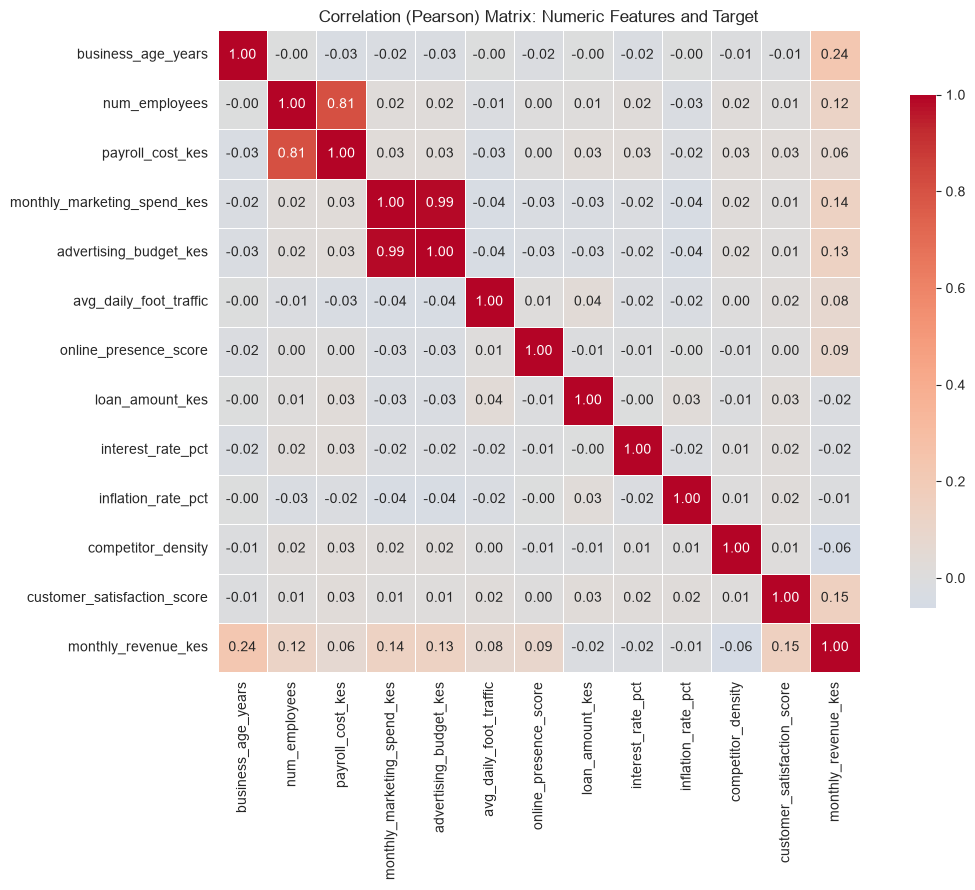

In [15]:
plt.figure(figsize=(12, 9))

corr_matrix = sme_data[numeric_cols].corr(method="pearson")
# `cbar_kws` stands for "colorbar keyword arguments."
# shrink=0.8 makes the colorbar 80% of its default length.
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation (Pearson) Matrix: Numeric Features and Target")
plt.tight_layout()
plt.show()

**Notes on Modelling Decisions:**

There are two near-duplicate predictor pairs in the heatmap:
- `num_employees` with `payroll_cost_kes`, and
- `advertising_budget_kes` with `monthly_marketing_spend_kes`.

These are flagged deliberately now and will be handled during the feature selection stage.

### Basic Visualizations

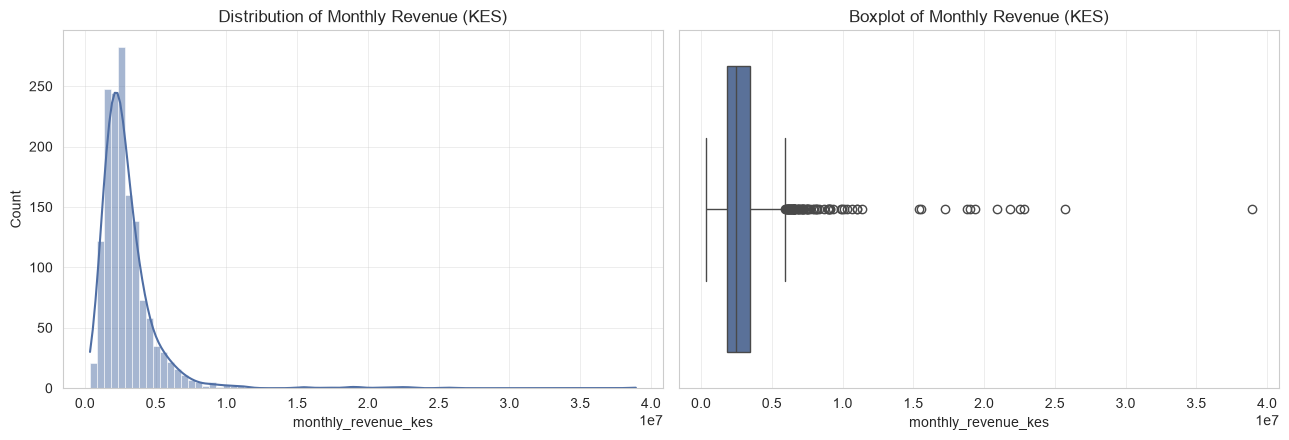

In [16]:
# `fig` is the whole container (the entire image).
# `axes` is a collection of subplot objects you plot into.
# `(1, 2)` means 1 row, 2 columns → two side-by-side plots.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# `ax=axes[0]` / `ax=axes[1]`: tells Seaborn which subplot to draw on.`
# `kde=True`: overlays a smooth density curve (Kernel Density
# Estimate) on top of the histogram. This is so that you can see the overall
# shape of the distribution more smoothly than bars alone.
sns.histplot(sme_data[TARGET], kde=True, ax=axes[0], color="#4F6EA4")
axes[0].set_title("Distribution of Monthly Revenue (KES)")

sns.boxplot(x=sme_data[TARGET], ax=axes[1], color="#4F6EA4")
axes[1].set_title("Boxplot of Monthly Revenue (KES)")

plt.tight_layout()
plt.show()

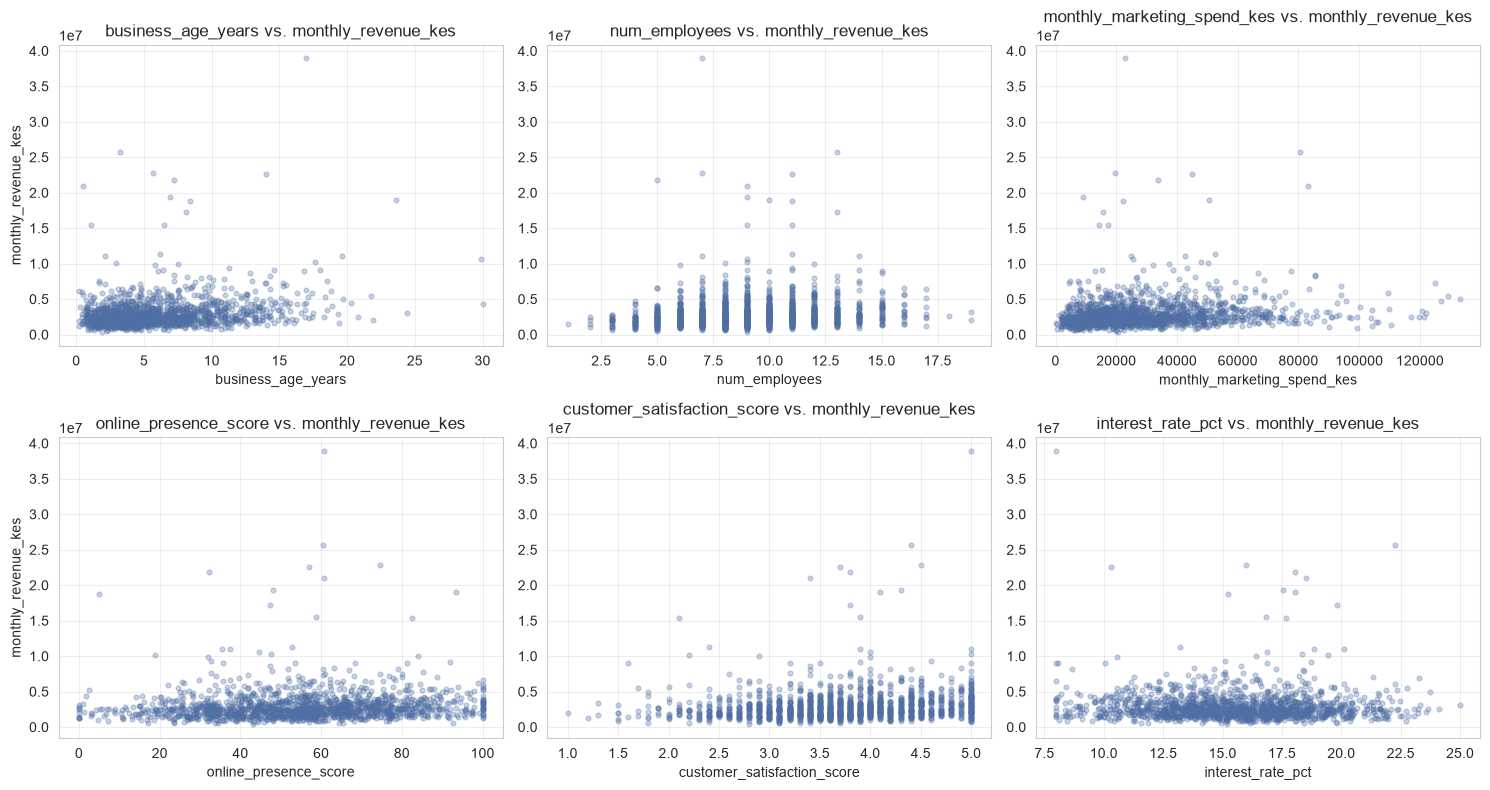

In [17]:
# `key_predictors` is the list of predictor column names.
# These are manually selected as those with at least +/-0.1 correlation
# (Pearson) at this point for further investigation.

key_predictors = [
    "business_age_years", "num_employees",
    "monthly_marketing_spend_kes",
    "online_presence_score", "customer_satisfaction_score",
    "interest_rate_pct"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# axes is a 2D *array* of subplot slots (from plt.subplots(2, 3, ...))
# `axes.flatten()` turns it into a 1D *list* of axes: [ax1, ax2, ..., ax6].
# `zip(axes.flatten(), key_predictors)` pairs them one-by-one.
# So each loop gives:
#   ax = one subplot to draw on
#   col = one feature name to plot on that subplot

# It therefore maps each predictor to one subplot automatically.

for ax, col in zip(axes.flatten(), key_predictors):
    ax.scatter(sme_data[col], sme_data[TARGET], alpha=0.3, s=12, color="#4F6EA4")
    ax.set_xlabel(col)
    # ax.set_ylabel(TARGET if col == key_predictors[0] else "")
    ax.set_ylabel(TARGET if col in (key_predictors[0], key_predictors[3]) else "")
    ax.set_title(f"{col} vs. {TARGET}")

plt.tight_layout()
plt.show()

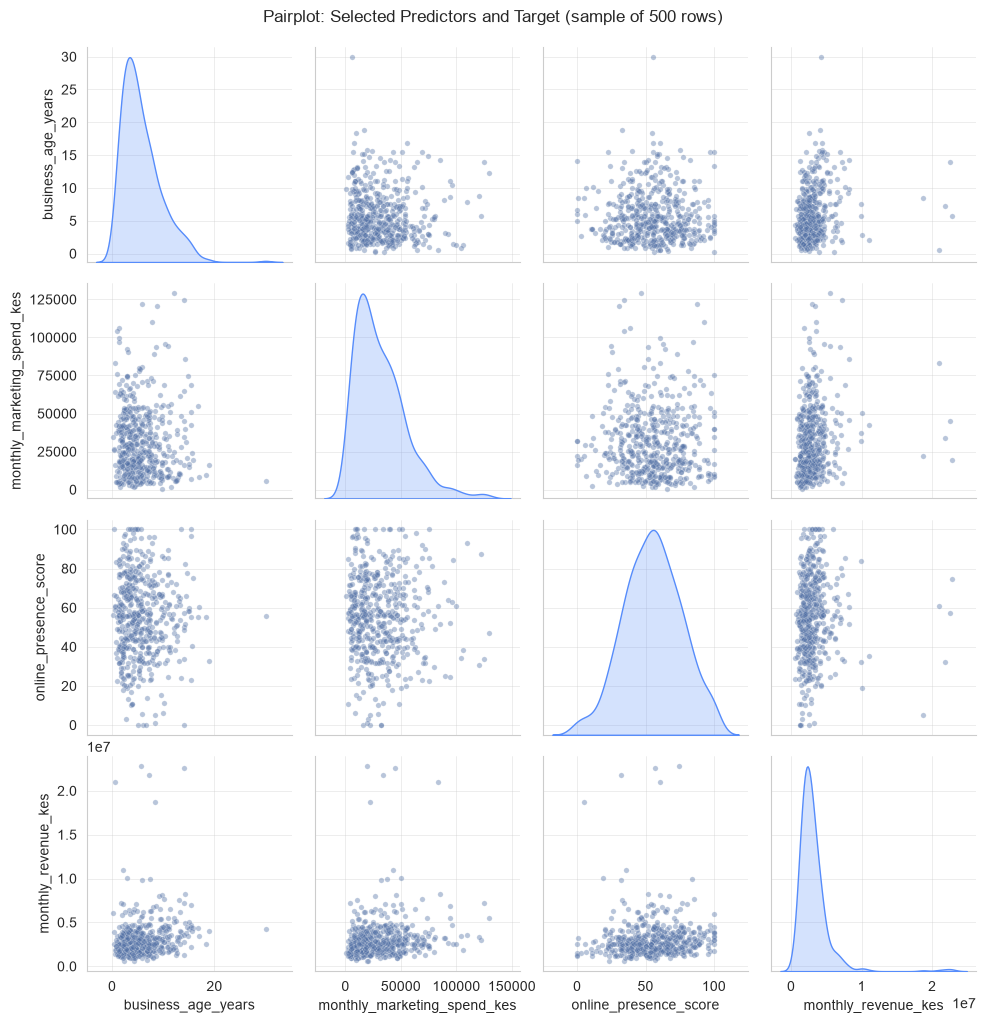

In [18]:
pairplot_cols = [
    "business_age_years",
    "monthly_marketing_spend_kes",
    "online_presence_score", TARGET]

# `diag_kind="kde"` Controls the diagonal plots (each variable vs itself).
# With "kde", seaborn draws a smooth density curve using Kernel Density
# Estimation instead of a histogram.

# `plot_kws={...}`: Keyword arguments (args) for the off-diagonal plots (the
# scatter plots between variable pairs):
#   "alpha": point transparency (lower value = more see-through)
#   "s": point size
#   "color": point color in hexadecimal

sns.pairplot(sme_data[pairplot_cols].sample(500, random_state=RANDOM_STATE), diag_kind="kde",
             plot_kws={"alpha": 0.4, "s": 15, "color": "#4F6EA4"})

plt.suptitle("Pairplot: Selected Predictors and Target (sample of 500 rows)", y=1.02)
plt.show()

## Train/Test Split

**This step MUST be done before feature selection and preprocessing.**
Fitting scalers, encoders, or performing feature selection on the full dataset
before splitting **leaks** information from the test set into training,
producing invalid model performance estimates.

**Notes on Modelling Decisions:**

Because `monthly_revenue_kes` is right-skewed (as identified during the
initial EDA), we stratify the split on a binned version of the target so that
both the training and test sets contain a comparable mix of low-, medium-, and
high-revenue enterprises.

**Binning means dividing a continuous target variable into discrete intervals (bins).**

In this case, we use quantile-based binning (`pd.qcut`) to create 5 bins, ensuring that each bin contains approximately the same number of observations. This helps to maintain the distribution of the target variable across both training and test sets. This is useful in cases where the target variable is not uniformly distributed.

In [19]:
from sklearn.model_selection import train_test_split

# Create a temporary binned target purely for stratification purposes

# `pd.qcut(sme_data[TARGET], q=5, ...)` splits revenue into 5 bins (quintiles).
# Each bin has roughly the same number of rows.
# `labels=False` gives bins numeric IDs, e.g., 0,1,2,3,4.
# duplicates="drop" tells qcut() to remove duplicate bin edges instead of raising an error.

revenue_bins = pd.qcut(sme_data[TARGET], q=5, labels=False, duplicates="drop")

feature_cols = [c for c in sme_data.columns if c not in ["business_id", TARGET]]

X = sme_data[feature_cols].copy()
y = sme_data[TARGET].copy()

# `stratify=revenue_bins` uses the already created bins to perform a
# balanced split in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=revenue_bins
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"Training target mean: {y_train.mean():,.0f} KES | Test target mean: {y_test.mean():,.0f} KES")

Training set: 1200 rows
Test set: 300 rows
Training target mean: 2,955,122 KES | Test target mean: 3,114,981 KES


## Feature Selection *(performed on training data ONLY)*

All feature selection below uses `X_train` and `y_train` exclusively. The test set is not
touched until the final evaluation stage.

### Correlation-based filtering (near-duplicate predictors)

In [20]:
print(f"The starting features are {len(X_train.columns)}: {list(X_train.columns)}")

The starting features are 16: ['sector', 'county', 'quarter', 'business_age_years', 'num_employees', 'payroll_cost_kes', 'owner_education_level', 'monthly_marketing_spend_kes', 'advertising_budget_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'loan_amount_kes', 'interest_rate_pct', 'inflation_rate_pct', 'competitor_density', 'customer_satisfaction_score']


In [21]:
numeric_train = X_train.select_dtypes(include=[np.number])
train_corr = numeric_train.corr(method="pearson").abs()

# We start by identifying pairs with a correlation above 0.9 → candidates
# for dropping one of the pair
high_corr_pairs = []

# Loop through each predictor column index
for i in range(len(train_corr.columns)):
    # Compare with columns to the right only (avoids duplicate/self-comparisons)
    for j in range(i + 1, len(train_corr.columns)):
        # We store only strong correlations (>0.8)
        # `iloc` means integer-location indexing in Pandas.
        #   It selects rows/columns by position (0-based), not by label/name.
        #   Format: df.iloc[row_index, col_index]
        if train_corr.iloc[i, j] > 0.8:
            # Store: (feature_1, feature_2, correlation rounded to 3 decimal places)
            high_corr_pairs.append(
                (train_corr.columns[i], train_corr.columns[j], round(train_corr.iloc[i, j], 3))
            )

print("Highly correlated predictor pairs (|r| > 0.80):")
for pair in high_corr_pairs:
    print(f"  {pair[0]}  <->  {pair[1]}   r = {pair[2]}")

Highly correlated predictor pairs (|r| > 0.80):
  num_employees  <->  payroll_cost_kes   r = 0.801
  monthly_marketing_spend_kes  <->  advertising_budget_kes   r = 0.99


**Notes for Modelling Decisions:**

We drop:
- `payroll_cost_kes` (redundant with, and also a function of, `num_employees`) and
- `advertising_budget_kes` (redundant with `monthly_marketing_spend_kes`).

Retaining both members of each pair would inflate variance in the coefficient estimates
of linear models without adding genuine information.

In [22]:
columns_to_drop_corr = ["payroll_cost_kes", "advertising_budget_kes"]
X_train_corr = X_train.drop(columns=columns_to_drop_corr)

print(f"The remaining features are {len(X_train_corr.columns)}: {list(X_train_corr.columns)}")

The remaining features are 14: ['sector', 'county', 'quarter', 'business_age_years', 'num_employees', 'owner_education_level', 'monthly_marketing_spend_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'loan_amount_kes', 'interest_rate_pct', 'inflation_rate_pct', 'competitor_density', 'customer_satisfaction_score']


### Variance Inflation Factor (VIF)

**VIF measures how much the variance of an estimated regression coefficient is inflated because a predictor is linearly related to other predictors.** A common rule of thumb considers VIF > 5 worthy of investigation and VIF > 10 a strong indication of **multicollinearity**.

VIF requires a fully numeric, **non-missing** matrix, so we compute it on a simple median-imputed numeric subset purely for diagnostic purposes. This is not the data imputation used in the final pipeline.

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_for_vif = X_train_corr.select_dtypes(include=[np.number]).copy()
numeric_for_vif = numeric_for_vif.fillna(numeric_for_vif.median())

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_for_vif.columns

# Compute VIF for each numeric predictor column (index i)
#   `numeric_for_vif.values` = matrix of predictor values
#   `variance_inflation_factor(..., i)` = VIF score for column i
# `numeric_for_vif.shape[1]` returns the number of columns in the DataFrame.
vif_data["VIF"] = [variance_inflation_factor(numeric_for_vif.values, i) for i in range(numeric_for_vif.shape[1])]  # loop over all columns
vif_data.sort_values("VIF", ascending=False).round(2)

,feature,VIF
7,inflation_rate_pct,62.66
6,interest_rate_pct,23.75
9,customer_satisfaction_score,23.55
1,num_employees,11.32
4,online_presence_score,7.38
8,competitor_density,6.60
3,avg_daily_foot_traffic,4.03
0,business_age_years,3.20
2,monthly_marketing_spend_kes,2.93
5,loan_amount_kes,1.52


In [24]:
# Chosen threshold
vif_threshold = 50

high_vif_features = vif_data.loc[vif_data["VIF"] > vif_threshold, "feature"].tolist()
print("High-VIF features:", high_vif_features)

X_train_corr_vif = X_train_corr.drop(columns=high_vif_features, errors="ignore")

# shape[0] returns the number of rows in a DataFrame
print(f"Train set shape: {X_train_corr_vif.shape[0]} rows, {X_train_corr_vif.shape[1]} columns")

print(f"The remaining features are {len(X_train_corr_vif.columns)}: {list(X_train_corr_vif.columns)}")

High-VIF features: ['inflation_rate_pct']
Train set shape: 1200 rows, 13 columns
The remaining features are 13: ['sector', 'county', 'quarter', 'business_age_years', 'num_employees', 'owner_education_level', 'monthly_marketing_spend_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'loan_amount_kes', 'interest_rate_pct', 'competitor_density', 'customer_satisfaction_score']


We confirm that the removal of features with a high VIF has reduced multicollinearity in the remaining numeric predictors.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_for_vif = X_train_corr_vif.select_dtypes(include=[np.number]).copy()
numeric_for_vif = numeric_for_vif.fillna(numeric_for_vif.median())

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_for_vif.columns

# Compute VIF for each numeric predictor column (index i)
#   `numeric_for_vif.values` = matrix of predictor values
#   `variance_inflation_factor(..., i)` = VIF score for column i
# `numeric_for_vif.shape[1]` returns the number of columns in the DataFrame.
vif_data["VIF"] = [variance_inflation_factor(numeric_for_vif.values, i) for i in range(numeric_for_vif.shape[1])]  # loop over all columns
vif_data.sort_values("VIF", ascending=False).round(2)

,feature,VIF
6,interest_rate_pct,17.93
8,customer_satisfaction_score,17.80
1,num_employees,10.19
4,online_presence_score,6.85
7,competitor_density,6.21
3,avg_daily_foot_traffic,3.92
0,business_age_years,3.10
2,monthly_marketing_spend_kes,2.86
5,loan_amount_kes,1.51


### Recursive Feature Elimination (RFE)

RFE fits a model repeatedly, removing the weakest predictor(s) at each
iteration. We use a simple linear model as the estimator and rank all numeric
features (categorical features are handled separately via the encoding pipeline).

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.impute import SimpleImputer

numeric_train_imputed = SimpleImputer(strategy="median").fit_transform(
    X_train_corr_vif.select_dtypes(include=[np.number])
)
numeric_feature_names = X_train_corr_vif.select_dtypes(include=[np.number]).columns

rfe_estimator = LinearRegression()
# `n_features_to_select` is currently a manual choice.
# Hyperparameter tuning can be used as a potential improvement.
rfe_selector = RFECV(
    estimator=rfe_estimator,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rfe_selector.fit(numeric_train_imputed, y_train)

rfe_ranking = pd.DataFrame({
    "feature": numeric_feature_names,
    "selected": rfe_selector.support_,
    "rank": rfe_selector.ranking_,
}).sort_values("rank")

rfe_ranking

,feature,selected,rank
0,business_age_years,True,1
1,num_employees,True,1
2,monthly_marketing_spend_kes,True,1
3,avg_daily_foot_traffic,True,1
4,online_presence_score,True,1
6,interest_rate_pct,True,1
7,competitor_density,True,1
8,customer_satisfaction_score,True,1
5,loan_amount_kes,False,2


In [27]:
# Numeric columns selected by RFE
selected_numeric_features = numeric_feature_names[rfe_selector.support_].tolist()

# We maintain all categorical columns (object/category/bool)
categorical_features = X_train_corr_vif.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Final feature list = selected numeric + all categorical
selected_features_mixed = selected_numeric_features + categorical_features

# Apply same columns to train
X_train_corr_vif_rfe = X_train_corr_vif[selected_features_mixed].copy()

print(f"Train set shape: {X_train_corr_vif_rfe.shape[0]} rows, {X_train_corr_vif_rfe.shape[1]} columns")

print("Selected numeric features by RFE:", selected_numeric_features)
print("Retained categorical features:", categorical_features)

print(f"The remaining features are {len(X_train_corr_vif_rfe.columns)}: {list(X_train_corr_vif_rfe.columns)}")

Train set shape: 1200 rows, 12 columns
Selected numeric features by RFE: ['business_age_years', 'num_employees', 'monthly_marketing_spend_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'interest_rate_pct', 'competitor_density', 'customer_satisfaction_score']
Retained categorical features: ['sector', 'county', 'quarter', 'owner_education_level']
The remaining features are 12: ['business_age_years', 'num_employees', 'monthly_marketing_spend_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'interest_rate_pct', 'competitor_density', 'customer_satisfaction_score', 'sector', 'county', 'quarter', 'owner_education_level']


### Lasso-Based Selection (shrinkage to zero)

LASSO (Least Absolute Shrinkage and Selection Operator) adds a penalty to the regression model.

The penalty shrinks coefficient values toward zero. Some coefficients may become exactly zero, effectively removing them from the model.

In [28]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Keep only numeric features and fill missing values with the column median
numeric_train_imputed = SimpleImputer(strategy="median").fit_transform(
    X_train_corr_vif_rfe.select_dtypes(include=[np.number])
)

numeric_feature_names = X_train_corr_vif_rfe.select_dtypes(include=[np.number]).columns

# We standardize features. This is important for Lasso so that the penalty is
# applied fairly.

# StandardScaler() standardizes numeric features so that each has a mean of 0
# and a standard deviation of 1. It does this by subtracting the mean from
# each value and then diving the result by the standard deviation.
scaler_for_lasso = StandardScaler()
numeric_train_scaled = scaler_for_lasso.fit_transform(numeric_train_imputed)

# Fit Lasso with 5-fold Cross Validation (CV) to automatically choose best
# regularization strength (alpha)
lasso_selector = LassoCV(cv=5, random_state=RANDOM_STATE).fit(numeric_train_scaled, y_train)

# Build a table of feature coefficients; larger absolute value → stronger effect
# Coefficients near/at 0 indicate weak or excluded features

# `key=abs` tells `sort_values()` to sort using the absolute value of each
# coefficient.
lasso_coefs = pd.DataFrame({
    "feature": numeric_feature_names,
    "lasso_coefficient": lasso_selector.coef_
}).sort_values("lasso_coefficient", key=abs, ascending=False)

# Display ranked coefficients
lasso_coefs

,feature,lasso_coefficient
0,business_age_years,446626.503365
2,monthly_marketing_spend_kes,275578.139962
7,customer_satisfaction_score,273798.570325
1,num_employees,262922.588111
4,online_presence_score,198556.427318
6,competitor_density,-141006.828784
3,avg_daily_foot_traffic,97226.542484
5,interest_rate_pct,-11997.932208


In [29]:
# We specify a tiny threshold to treat near-zero coefficients as removable
coef_threshold = 1e-6

# Numeric features to keep based on Lasso importance
selected_lasso_numeric_features = lasso_coefs.loc[
    lasso_coefs["lasso_coefficient"].abs() > coef_threshold, "feature"
].tolist()

# Numeric features dropped by Lasso
dropped_lasso_numeric_features = [
    f for f in numeric_feature_names if f not in selected_lasso_numeric_features
]

# Retain all categorical features from the current
# Person's Correlation + RFE + VIF feature set
categorical_features_after_rfe = X_train_corr_vif_rfe.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Final feature list: selected numeric + all categorical
selected_lasso_mixed_features = selected_lasso_numeric_features + categorical_features_after_rfe

print("Selected numeric features by Lasso:", selected_lasso_numeric_features)
print("Dropped numeric features by Lasso:", dropped_lasso_numeric_features)
print("Retained categorical features:", categorical_features_after_rfe)

# Apply to train
X_train_corr_vif_rfe_lasso = X_train_corr_vif_rfe[selected_lasso_mixed_features].copy()

print("Final mixed train shape:", X_train_corr_vif_rfe_lasso.shape)
print(f"The remaining features are {len(X_train_corr_vif_rfe.columns)}: {list(X_train_corr_vif_rfe.columns)}")

Selected numeric features by Lasso: ['business_age_years', 'monthly_marketing_spend_kes', 'customer_satisfaction_score', 'num_employees', 'online_presence_score', 'competitor_density', 'avg_daily_foot_traffic', 'interest_rate_pct']
Dropped numeric features by Lasso: []
Retained categorical features: ['sector', 'county', 'quarter', 'owner_education_level']
Final mixed train shape: (1200, 12)
The remaining features are 12: ['business_age_years', 'num_employees', 'monthly_marketing_spend_kes', 'avg_daily_foot_traffic', 'online_presence_score', 'interest_rate_pct', 'competitor_density', 'customer_satisfaction_score', 'sector', 'county', 'quarter', 'owner_education_level']


### Domain-driven exclusion

**Notes on Modelling Decisions:**

`business_id` was already excluded in the previous stages (a Primary Key from a
database, with no predictive meaning). No further domain-driven exclusions are
applied here; all remaining features have a plausible business rationale for
influencing revenue.

## Data Preprocessing and Data Transformation *(performed on training data ONLY)*

Data transforms can improve the accuracy of your final model when applied
before the modelling stage. It is standard practice to apply multiple
transforms. Data transforms can be grouped into the following 3 categories:

- Basic data transforms:
  - **Scaling:** Divides each value by the standard deviation
  - **Centering:** Subtracts the mean from each value
  - **Standardization:** Ensures that each numeric attribute has a
     mean value of 0 and a standard deviation of 1. This is done
     by combining the scale data transform and the centre data
     transform: subtract the mean and divide by the standard deviation.
  - **Normalization:** Ensures the numerical data are between [0, 1]
     (inclusive).

- Power data transforms:
  - **Box-Cox:** reduces the skewness by shifting the distribution of
  an attribute and making the attribute have a more
  Gaussian-like distribution.
  - **Yeo-Johnson:** like Box-Cox, Yeo-Johnson reduces the skewness
  by shifting the distribution of an attribute and making the
  attribute have a more Gaussian-like distribution.
  The difference is that Yeo-Johnson can handle zero and
  negative values.

- Logarithmic data transforms:
  - **log1p: logarithm of (1 + x):** Applies a logarithmic transformation that
  helps reduce right-skewness and compress large values for non-negative data.
  It can also handle zero values, making it useful for variables such as revenue or counts.


**Notes on Modelling Decisions:**

All transformers below are fit on the **train set only**, using
`sklearn.pipeline.Pipeline` and `ColumnTransformer` so that the identical fitted
transformation is applied to the test set with `.transform()`, instead of `.fit_transform()`.

### Encoding

- One-hot encoding for nominal categoricals: `sector`, `county`, `quarter`
- Ordinal encoding for `owner_education_level` (natural order: `Primary` < `Secondary` < `Certificate` < `Diploma` < `Bachelor's` < `Master's` < `Doctorate`)

### Handling Missing Data

- `avg_daily_foot_traffic`: missing for Technology-sector (online only)
  businesses (it is structurally not applicable. Therefore, it is not missing
  at random). We use median imputation plus a missingness indicator column, so
  that the model can learn that "online business" is itself informative.
- `customer_satisfaction_score`: missing at random (~5%, non-response).
  We also use median imputation here.

### Class Imbalance

Not applicable. The target, `monthly_revenue_kes`, is continuous, ratio
scale data, not a set of class labels; class imbalance is a classification
concept.

### Scaling / Centering / Standardization

`StandardScaler` is applied to numeric features, needed for the linear, Ridge,
Lasso, ElasticNet, and Support Vector Regressor (SVR) models used later.
Tree-based models are insensitive to scaling, but a single shared pipeline is
used for comparability across all models.

### Box-Cox / Yeo-Johnson / log1p

The target is strictly positive (revenue cannot be zero or negative in this dataset), so
we apply a **log1p transform** to the target for modeling purposes (a common, simple, and
directly invertible alternative to Box-Cox for a strictly positive, right-skewed target),
and separately *demonstrate* Box-Cox/Yeo-Johnson on a skewed predictor using
`PowerTransformer`.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

nominal_cols = ["sector", "county", "quarter"]
ordinal_col = ["owner_education_level"]
# OrdinalEncoder expects a list of category lists: one category list for each ordinal column.
education_order = [["Primary", "Secondary", "Certificate", "Diploma", "Bachelors", "Masters", "Doctorate"]]

# Numeric columns split: one requires a missingness indicator (structural missingness)
foot_traffic_col = ["avg_daily_foot_traffic"]
other_numeric_cols = [c for c in X_train_corr_vif_rfe_lasso.select_dtypes(include=[np.number]).columns
                       if c not in foot_traffic_col]

# `add_indicator=True` tells `SimpleImputer` to add an extra binary column
# indicating which values were originally missing.
foot_traffic_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# `strategy="most_frequent" replaces missing categorical values with the
# most frequently occurring category in that column.
nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=education_order)),
])

preprocessor = ColumnTransformer(transformers=[
    ("foot_traffic", foot_traffic_pipeline, foot_traffic_col),
    ("numeric", numeric_pipeline, other_numeric_cols),
    ("nominal", nominal_pipeline, nominal_cols),
    ("ordinal", ordinal_pipeline, ordinal_col),
])

print("Preprocessing pipeline constructed.")
print(f"Foot traffic (structural missingness + indicator): {foot_traffic_col}")
print(f"Other numeric columns ({len(other_numeric_cols)}): {other_numeric_cols}")
print(f"Nominal columns (one-hot): {nominal_cols}")
print(f"Ordinal column: {ordinal_col}")

Preprocessing pipeline constructed.
Foot traffic (structural missingness + indicator): ['avg_daily_foot_traffic']
Other numeric columns (7): ['business_age_years', 'monthly_marketing_spend_kes', 'customer_satisfaction_score', 'num_employees', 'online_presence_score', 'competitor_density', 'interest_rate_pct']
Nominal columns (one-hot): ['sector', 'county', 'quarter']
Ordinal column: ['owner_education_level']


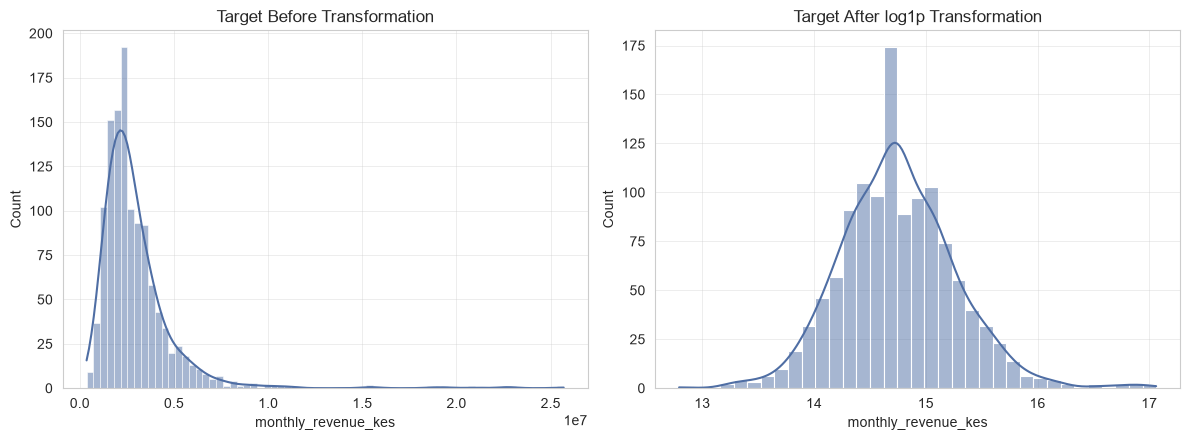

Skewness before: 4.76
Skewness after log1p transformation: 0.39


In [31]:
# Target transformation: log1p (strictly positive, right-skewed target)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(y_train, kde=True, ax=axes[0], color="#4F6EA4")
axes[0].set_title("Target Before Transformation")

sns.histplot(y_train_log, kde=True, ax=axes[1], color="#4F6EA4")
axes[1].set_title("Target After log1p Transformation")
plt.tight_layout()
plt.show()

print(f"Skewness before: {y_train.skew():.2f}")
print(f"Skewness after log1p transformation: {y_train_log.skew():.2f}")

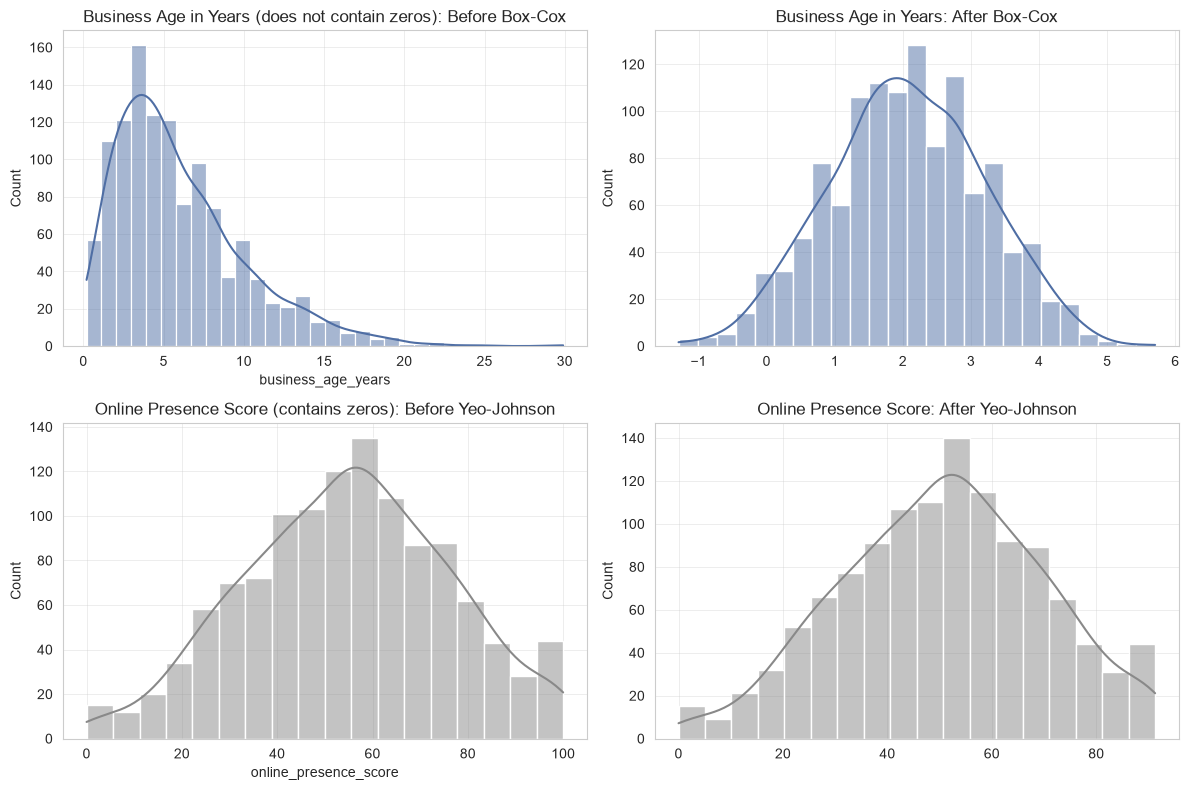

Note: Box-Cox requires strictly positive input. `online_presence_score` contains zeros
(businesses with no social media account or website), so Yeo-Johnson is the correct choice in the case of `online_presence_score`.
Skewness of business age in years spend before: 1.30
Skewness of business age in years spend after Box-Cox transformation: -0.02
Skewness of online presence before: -0.09
Skewness of online presence after Yeo-Johnson transformation: -0.11


In [32]:
# Demonstration Purposes Only: Box-Cox / Yeo-Johnson on a skewed predictor
# business_age_years is strictly positive and right-skewed -- a good
# Box-Cox candidate
demo_feature = X_train_corr_vif_rfe_lasso[["business_age_years"]].copy()

boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
demo_feature_boxcox = boxcox_transformer.fit_transform(demo_feature)

# loan_amount_kes contains zeros, so Box-Cox is invalid (requires strictly positive values);
# Yeo-Johnson handles zero and negative values and is used instead.
demo_feature_zero = X_train_corr_vif_rfe_lasso[["online_presence_score"]].copy()

yeojohnson_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
demo_feature_yj = yeojohnson_transformer.fit_transform(demo_feature_zero)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(demo_feature["business_age_years"], kde=True, ax=axes[0, 0], color="#4F6EA4")
axes[0, 0].set_title("Business Age in Years (does not contain zeros): Before Box-Cox")

sns.histplot(demo_feature_boxcox.flatten(), kde=True, ax=axes[0, 1], color="#4F6EA4")
axes[0, 1].set_title("Business Age in Years: After Box-Cox")

sns.histplot(demo_feature_zero["online_presence_score"], kde=True, ax=axes[1, 0], color="#898989")
axes[1, 0].set_title("Online Presence Score (contains zeros): Before Yeo-Johnson")

sns.histplot(demo_feature_yj.flatten(), kde=True, ax=axes[1, 1], color="#898989")
axes[1, 1].set_title("Online Presence Score: After Yeo-Johnson")

plt.tight_layout()
plt.show()

print("Note: Box-Cox requires strictly positive input. `online_presence_score` contains zeros")
print("(businesses with no social media account or website), so Yeo-Johnson is the correct choice in the case of `online_presence_score`.")

print(f"Skewness of business age in years spend before: {sme_data["business_age_years"].skew():.2f}")
# [:, 0] means "select all rows, but only column 0." It converts a single-column 2D array into a 1-dimensional array.
print(f"Skewness of business age in years spend after Box-Cox transformation: {pd.Series(demo_feature_boxcox[:, 0]).skew():.2f}")

print(f"Skewness of online presence before: {sme_data["online_presence_score"].skew():.2f}")
print(f"Skewness of online presence after Yeo-Johnson transformation: {pd.Series(demo_feature_yj[:, 0]).skew():.2f}")

## Machine Learning Pipeline and Cross-Validation

Each candidate model is wrapped in the same `preprocessor` from the previous step inside a single
`Pipeline`, so that preprocessing is refit correctly within each cross-validation fold
(preventing leakage across folds, not just across the train/test boundary). We model the
log-transformed target and will invert the transformation when reporting metrics in
actual currency (KES) terms.

In [33]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=6),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200, max_depth=8),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=200, max_depth=3),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

# Scikit-learn's cross_val_score() follows a convention where higher scores are
# always considered better. But RMSE is a loss, where lower is better.
# `-score` converts the negative RMSE values back to the normal, interpretable
# positive RMSE values.
print("Note: Lower RMSE is better.")
for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipeline, X_train_corr_vif_rfe_lasso, y_train_log, cv=kfold,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_results[name] = -scores
    print(f"{name:20s} RMSE (log scale): {-scores.mean():.4f}  (+/- {scores.std():.4f})")

Note: Lower RMSE is better.
Linear Regression    RMSE (log scale): 0.4013  (+/- 0.0455)
Ridge                RMSE (log scale): 0.4012  (+/- 0.0455)
Lasso                RMSE (log scale): 0.5173  (+/- 0.0439)
ElasticNet           RMSE (log scale): 0.5173  (+/- 0.0439)
Decision Tree        RMSE (log scale): 0.5111  (+/- 0.0318)
Random Forest        RMSE (log scale): 0.4289  (+/- 0.0438)
Gradient Boosting    RMSE (log scale): 0.4239  (+/- 0.0398)


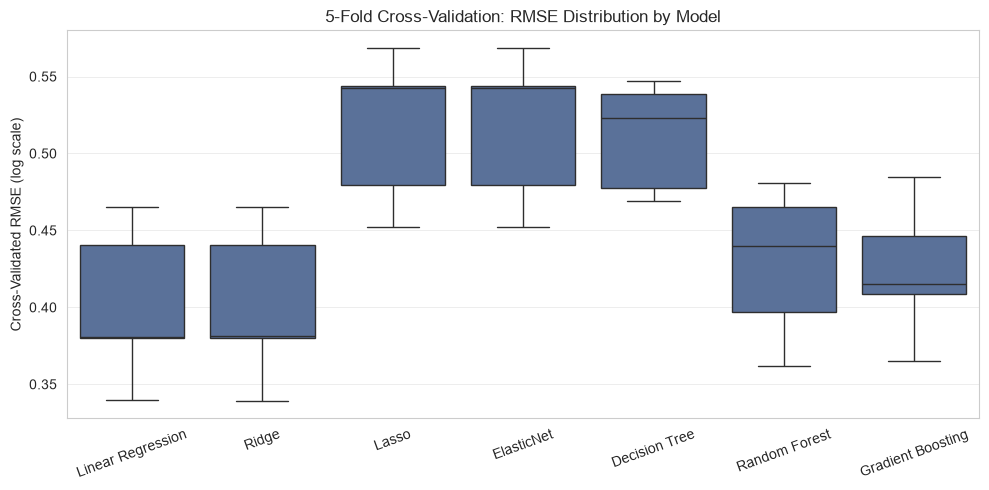

In [34]:
cv_results_df = pd.DataFrame(cv_results)
plt.figure(figsize=(10, 5))
sns.boxplot(data=cv_results_df, color="#4F6EA4")
plt.ylabel("Cross-Validated RMSE (log scale)")
plt.title("5-Fold Cross-Validation: RMSE Distribution by Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Bias-Variance Tradeoff: Learning Curves

A learning curve plots training and validation score as a function of training set size.
- **High bias** (underfitting): both curves converge to a low (poor) score, with a small gap.
- **High variance** (overfitting): a large, persistent gap between training and validation score.

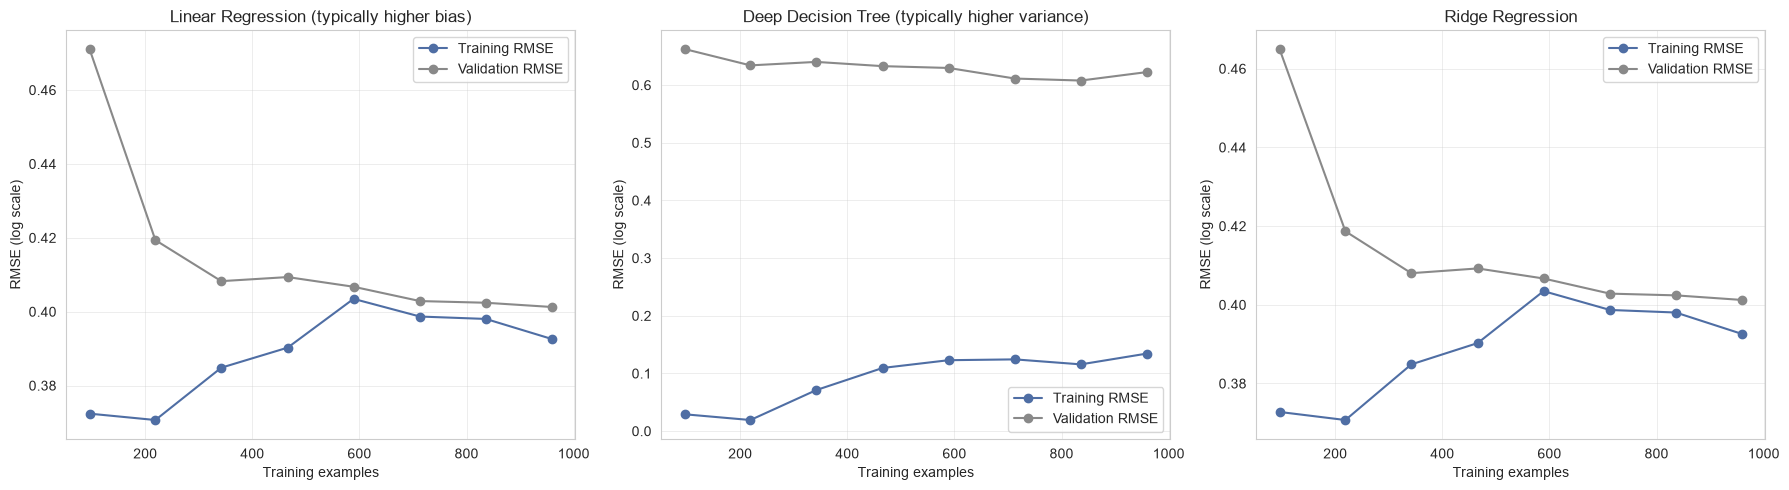

In [35]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=kfold,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_rmse, "o-", color="#4F6EA4", label="Training RMSE")
    ax.plot(train_sizes, val_rmse, "o-", color="#898989", label="Validation RMSE")
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("RMSE (log scale)")
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pipe_linear = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipe_tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=12))
])

pipe_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE))
])

plot_learning_curve(
    pipe_linear, X_train_corr_vif_rfe_lasso, y_train_log,
    "Linear Regression (typically higher bias)", axes[0]
)
plot_learning_curve(
    pipe_tree, X_train_corr_vif_rfe_lasso, y_train_log,
    "Deep Decision Tree (typically higher variance)", axes[1]
)
plot_learning_curve(
    pipe_ridge, X_train_corr_vif_rfe_lasso, y_train_log,
    "Ridge Regression", axes[2]
)

plt.tight_layout()
plt.show()

## Diagnostic Exploratory Data Analysis (Model Diagnostics)

Diagnostic Exploratory Data Analysis is performed to verify that the
assumptions underlying the regression model are satisfied. Confirming that
these assumptions hold ensures that the statistical tests used in the model are
valid for the data, thus reducing the risk of drawing incorrect or misleading
conclusions in your data analysis.

We use a fitted Linear Regression pipeline, because classical regression
diagnostics (residual structure, homoscedasticity, autocorrelation) are most
directly interpretable for a linear model. The linear model is fit once on the
full training set (not cross-validated) for this stage.


### Test of Linearity

The test of linearity is used to assess whether the relationship between the
dependent variable and the independent variable(s) is linear. This is necessary
given that linearity is one of the key assumptions of statistical tests of
regression, and verifying it is crucial for ensuring the validity of the
model's estimates and predictions.

#### Residuals vs. Fitted Values Plot

A plot of the **"residuals versus the fitted values"** enables us to test for
linearity. **For the model to pass the test of linearity, there should be no
pattern in the distribution of residuals and the residuals should be randomly
placed around the 0.0 residual line.**

### Test of Normality of the Distribution of the Errors

The test of normality of the distribution of the errors assesses whether the errors (residuals) are approximately normally distributed, i.e., most errors are close to zero and large errors are rare. A Q-Q plot can be used to conduct the test of normality.

#### Q-Q Plot

A Q-Q plot is a scatterplot of the quantiles of the errors against the quantiles of a normal distribution. Quantiles are statistical values that divide a dataset or probability distribution into equal-sized intervals. They help in understanding how data is distributed by marking specific points that separate the data into groups of equal size. Examples of quantiles include: quartiles (4 equal parts), deciles (10 equal parts), and percentiles (100 equal parts).

If the points show substantial departures from the straight diagonal line, then the normality assumption may not be satisfied.

In [36]:
linear_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
linear_pipeline.fit(X_train_corr_vif_rfe_lasso, y_train_log)

fitted_values = linear_pipeline.predict(X_train_corr_vif_rfe_lasso)
residuals = y_train_log.values - fitted_values

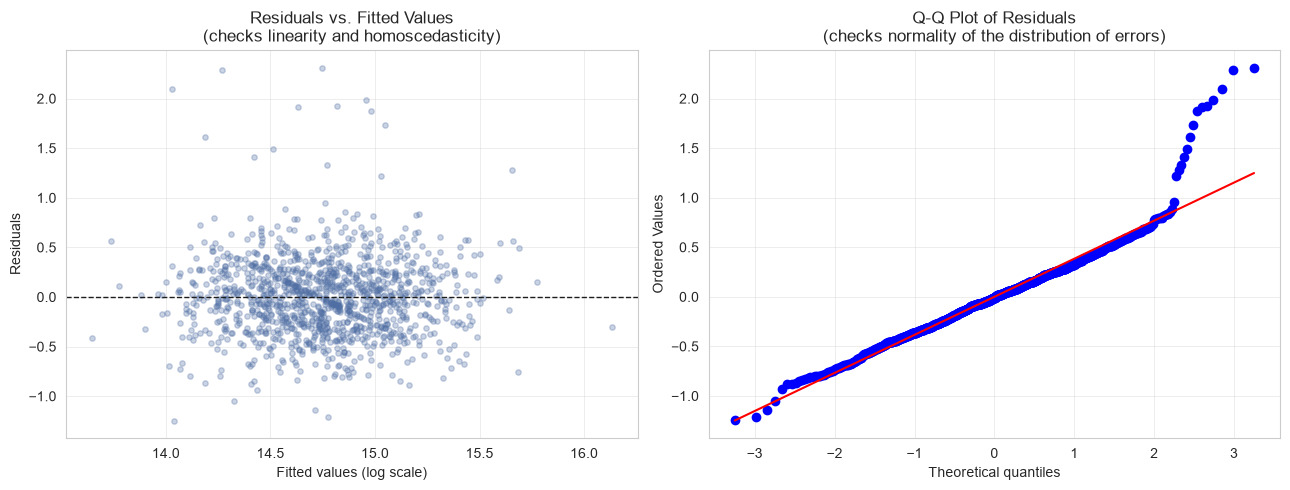

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(fitted_values, residuals, alpha=0.3, s=15, color="#4F6EA4")
axes[0].axhline(0, color="#1D1D1D", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted Values\n(checks linearity and homoscedasticity)")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals\n(checks normality of the distribution of errors)")

plt.tight_layout()
plt.show()

### Test of Homoscedasticity

#### Breusch-Pagan Test

The Breusch-Pagan Test can also be used to test for heteroscedasticity; a formal complement to visual inspections.

Formally:

- Null hypothesis (H₀): The spread of the variance of the error term is homoscedastic (equal variance).
- Alternative hypothesis (H₁): The spread of the variance of the error term is heteroscedastic (non-constant variance).

p-Value:
- p-value of the Breusch-Pagan LM Statistic ≥ 0.05: Fail to reject H₀ → no evidence of heteroscedasticity → this is good; model passes.
- p-value of the Breusch-Pagan LM Statistic < 0.05: Reject H₀ → evidence of heteroscedasticity → this is bad; model fails.

In [38]:
# Breusch-Pagan test for heteroscedasticity (formal complement to the visual check above)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

X_train_transformed = preprocessor.transform(X_train_corr_vif_rfe_lasso)
X_train_with_const = sm.add_constant(X_train_transformed)

bp_test = het_breuschpagan(residuals, X_train_with_const)
bp_labels = ["Breusch-Pagan LM (Lagrange Multiplier) Statistic", "Breusch-Pagan LM p-value", "F-Statistic", "F p-value"]
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.4f}")

Breusch-Pagan LM (Lagrange Multiplier) Statistic: 33.7875
Breusch-Pagan LM p-value: 0.1405
F-Statistic: 1.5500
F p-value: 0.0503


**Notes on Modelling Decisions:**

A large p-value (>0.05) implies no evidence of heteroscedasticity (constant
residual variance). This does not warrant a variance-stabilizing transformation.

### Test of Independence of Errors (Autocorrelation)

This test is necessary to **assess whether the regression errors are correlated across observations, particulary whe nobservations have a meaningful ordering such as time**. It, therefore, helps to identify autocorrelation that is introduced when the data is collected over a close period of time or when one observation is related to another observation.

- **Example 1:** Algorithm benchmarks run sequentially on the same machine, where thermal throttling, caching, or background load could make consecutive runs correlated.
- **Example 2:** A retail store's daily revenue observations collected over consecutive days may be correlated because a promotional campaign running today continues to drive carry-over purchases tomorrow. This means that each day's revenue is partly a function of the preceding day's revenue.

#### Durbin-Watson Test

Positive autocorrelation leads to underestimated standard errors and inflated t-statistics. It can also make findings appear more significant than they actually are with  artificially small p-values. The "Durbin-Watson Test" can be used as a test of independence of errors (test of autocorrelation). **A Durbin-Watson statistic close to 2 suggests little/no evidence of autocorrelation, while values approaching 0 or 4 indicate positive or negative autocorrelation, respectively.**

`0 ≤ DW ≤ 4`

where:

- `DW≈2`: little/no evidence of autocorrelation
- `DW<2`: positive autocorrelation
- `DW>2`: negative autocorrelation
- `DW→0`: strong positive autocorrelation
- `DW→4`: strong negative autocorrelation

In [39]:
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")

Durbin-Watson statistic: 1.9441


**Notes on Modelling Decisions:**

The dataset is cross-sectional (not a time series), therefore, we expect a value close to 2; a strong deviation would suggest an omitted ordering variable.

### Test of Multicollinearity

#### Variance Inflation Factor (VIF)

**VIF measures how much the variance of an estimated regression coefficient is inflated because a predictor is linearly related to other predictors.** A common rule of thumb considers VIF > 5 worthy of investigation and VIF > 10 a strong indication of **multicollinearity**.

VIF requires a fully numeric, **non-missing** matrix, so we compute it on a simple median-imputed numeric subset purely for diagnostic purposes. This is not the data imputation used in the final pipeline.

In [40]:
# VIF recheck on the final numeric feature set (post-feature-selection)
vif_recheck = pd.DataFrame()
vif_recheck["feature"] = numeric_feature_names
vif_recheck["VIF"] = [variance_inflation_factor(numeric_train_imputed, i) for i in range(numeric_train_imputed.shape[1])]
vif_recheck.sort_values("VIF", ascending=False).round(2)

,feature,VIF
5,interest_rate_pct,17.88
7,customer_satisfaction_score,17.67
1,num_employees,10.18
4,online_presence_score,6.85
6,competitor_density,6.21
3,avg_daily_foot_traffic,3.90
0,business_age_years,3.10
2,monthly_marketing_spend_kes,2.86


### Test of Outliers

Cook's distance measures how much a single observation influences the entire regression model. For each observation, it asks: *"If I removed this point and refit the model, how much would the predicted values change?"* A large Cook's distance means that one observation is disproportionately steering the coefficients.

Cook's distance is high when an observation is both:

- An outlier in y (large residual: the model predicts it poorly), and
- A high-leverage point in X (its predictor values are extreme or unusual relative to the rest of the data)

An observation with only one of these two properties is usually not influential. **It is the combination that matters**.

**Threshold:** A common rule of thumb is `4/n`, where `n` the number of observations in the training set used to fit the mode. Though it is a heuristic, not a statistical law. Points above it deserve **inspection**, **NOT** automatic removal.

**How to handle flagged observations:** Investigate before acting. They may be data entry errors, genuinely unusual (but valid) cases, or perhaps, deliberately injected anomalies. Only remove or downweight them if there is a substantive reason, not merely because the statistic is large.

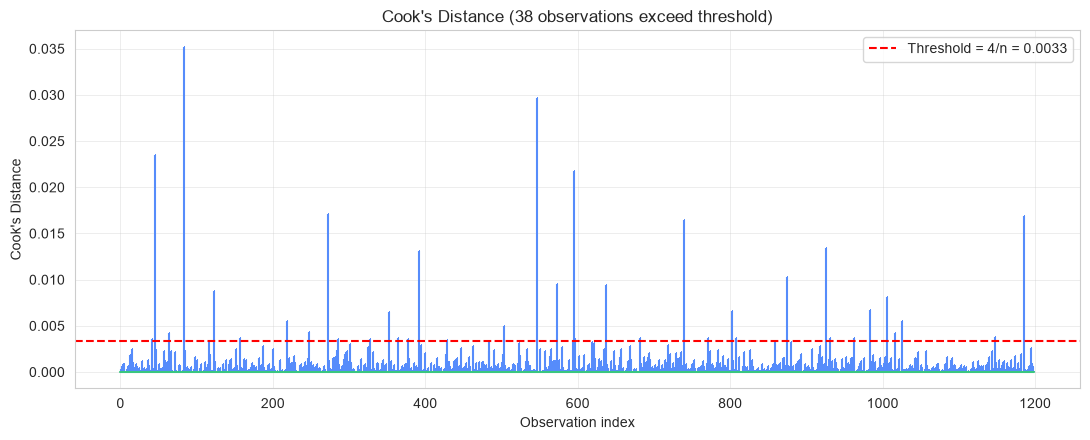

Number of influential observations flagged: 38 out of 1200
These are strong candidates for the injected high-revenue outliers noted in Stage 3.


In [41]:
influence = sm.OLS(y_train_log.values, X_train_with_const).fit()
cooks_d = influence.get_influence().cooks_distance[0]

influential_threshold = 4 / len(y_train_log)
n_influential = (cooks_d > influential_threshold).sum()

plt.figure(figsize=(11, 4.5))
plt.stem(cooks_d, markerfmt=",")
plt.axhline(influential_threshold, color="red", linestyle="--",
            label=f"Threshold = 4/n = {influential_threshold:.4f}")
plt.xlabel("Observation index")
plt.ylabel("Cook's Distance")
plt.title(f"Cook's Distance ({n_influential} observations exceed threshold)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Number of influential observations flagged: {n_influential} out of {len(y_train_log)}")
print("These are strong candidates for the injected high-revenue outliers noted in Stage 3.")

In [42]:
# List the flagged observations
influential_idx = np.where(cooks_d > influential_threshold)[0]

influential_summary = pd.DataFrame({
    "Observation Index in Dataset": influential_idx,
    "Cooks Distance": cooks_d[influential_idx]
}).sort_values("Cooks Distance", ascending=False).reset_index(drop=True)

print(f"Number of influential observations flagged: {n_influential} out of {len(y_train_log)}")
influential_summary

Number of influential observations flagged: 38 out of 1200


,Observation Index in Dataset,Cooks Distance
0,84,0.035215
1,547,0.029614
2,45,0.023541
3,595,0.021717
4,272,0.017149
5,1185,0.016889
6,740,0.016470
7,926,0.013378
8,392,0.013144
9,874,0.010315


## Evaluating the Performance of Several Models

All models are fit on the full training set and evaluated once on the held-out test set.
Metrics are reported in the **original KES scale** (after inverting the `log1p` transform
using `np.expm1`), since stakeholders reason in KES, not in log-revenue units.

`np.log1p(x)` computes `log(1 + x)`.
To reverse it, we use `np.expm1(y)`, which computes `exp(y) - 1`.

So if:

`y = np.log1p(x)`, then
`x = np.expm1(y)`

In other words, `np.expm1` is the inverse of `np.log1p`.

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

evaluation_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train_corr_vif_rfe_lasso, y_train_log)

    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = y_test.values

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, len(y_true), X_test.shape[1])
    mape = mean_absolute_percentage_error(y_true, y_pred)

    evaluation_results.append({
        "Model": name, "MAE (KES)": mae, "MSE": mse, "RMSE (KES)": rmse,
        "R2": r2, "Adjusted R2": adj_r2, "MAPE (%)": mape
    })

evaluation_df = pd.DataFrame(evaluation_results).sort_values("RMSE (KES)")
evaluation_df.style.format({
    "MAE (KES)": "{:,.0f}", "MSE": "{:,.0f}", "RMSE (KES)": "{:,.0f}",
    "R2": "{:.3f}", "Adjusted R2": "{:.3f}", "MAPE (%)": "{:.2f}"
})

,Model,MAE (KES),MSE,RMSE (KES),R2,Adjusted R2,MAPE (%)
0,Linear Regression,"1,047,765","7,017,863,645,795","2,649,125",0.252,0.209,32.45
1,Ridge,"1,047,732","7,021,363,938,312","2,649,786",0.251,0.209,32.45
6,Gradient Boosting,"1,150,298","7,231,035,716,680","2,689,059",0.229,0.185,35.93
5,Random Forest,"1,149,632","7,735,401,614,177","2,781,259",0.175,0.129,35.80
4,Decision Tree,"1,354,728","8,640,965,534,378","2,939,552",0.079,0.026,44.47
2,Lasso,"1,326,919","9,700,093,290,889","3,114,497",-0.034,-0.093,43.18
3,ElasticNet,"1,326,919","9,700,093,290,889","3,114,497",-0.034,-0.093,43.18


## Hyperparameter Tuning

Multiple "model families" are tuned using the same preprocessing pipeline and
cross-validation setup from the previous steps. We start with the linear
regularized models (`Ridge`, `Lasso`, and `ElasticNet`) because linear baselines
performed strongly. The search space is then extended to include tree-based
models such as `DecisionTreeRegressor`, `RandomForestRegressor`,
and `GradientBoostingRegressor` for comparison under the same evaluation protocol.

`GridSearchCV` reuses the same `KFold` cross-validation scheme and RMSE scoring to
ensure a fair model selection process.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# You can tune Ridge, Lasso, and ElasticNet under one search space
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())  # This is a placeholder; GridSearchCV will swap model via param_grid
])

param_grid = [
    {
        "model": [Ridge(random_state=RANDOM_STATE)],
        "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    {
        "model": [Lasso(random_state=RANDOM_STATE, max_iter=20000)],
        "model__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
    },
    {
        "model": [ElasticNet(random_state=RANDOM_STATE, max_iter=20000)],
        "model__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    },
    {
        "model": [GradientBoostingRegressor(random_state=RANDOM_STATE)],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.03, 0.1, 0.2],
        "model__subsample": [0.8, 1.0]
    }
]

grid_search_linear = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0
)

grid_search_linear.fit(X_train_corr_vif_rfe_lasso, y_train_log)

print(f"Best tuned linear model: {grid_search_linear.best_estimator_.named_steps['model']}")
print(f"Best parameters: {grid_search_linear.best_params_}")
print(f"Best CV RMSE (log scale): {-grid_search_linear.best_score_:.4f}")

Best tuned linear model: Lasso(alpha=0.001, max_iter=20000, random_state=42)
Best parameters: {'model': Lasso(max_iter=20000, random_state=42), 'model__alpha': 0.001}
Best CV RMSE (log scale): 0.4009


In [45]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Works whether the winner is Ridge/Lasso/ElasticNet/GradientBoosting/etc.
best_model = grid_search_linear.best_estimator_

# Identify the winning model type
best_model_name = best_model.named_steps["model"].__class__.__name__

# Predict (target was trained in log1p scale)
y_pred_log = best_model.predict(X_test)
y_pred_kes = np.expm1(y_pred_log)
y_true_kes = y_test.values

# Metrics in original scale (KES)
rmse_kes = np.sqrt(mean_squared_error(y_true_kes, y_pred_kes))
mae_kes = mean_absolute_error(y_true_kes, y_pred_kes)
r2 = r2_score(y_true_kes, y_pred_kes)

print(f"Best tuned model: {best_model_name}")
print(f"Best params: {grid_search_linear.best_params_}")
print(f"Best CV RMSE (log scale): {-grid_search_linear.best_score_:.4f}")
print(f"Test MAE: {mae_kes:,.0f} KES | Test RMSE: {rmse_kes:,.0f} KES | Test R2: {r2:.3f}")

Best tuned model: Lasso
Best params: {'model': Lasso(max_iter=20000, random_state=42), 'model__alpha': 0.001}
Best CV RMSE (log scale): 0.4009
Test MAE: 1,047,628 KES | Test RMSE: 2,654,884 KES | Test R2: 0.248


**[Optional] for a more advanced challenge**: we can replace `GridSearchCV` with
a Bayesian optimization library such as `optuna`, which can search the
hyperparameter space more efficiently than an exhaustive grid. Especially as
the number of tuned parameters grows.

## Explainability

### Coefficient Interpretation

Because numeric features were standardized in the preprocessing pipeline, the linear
model's coefficients are directly comparable in magnitude: a larger absolute coefficient
indicates a stronger association with log-revenue, holding other features constant.

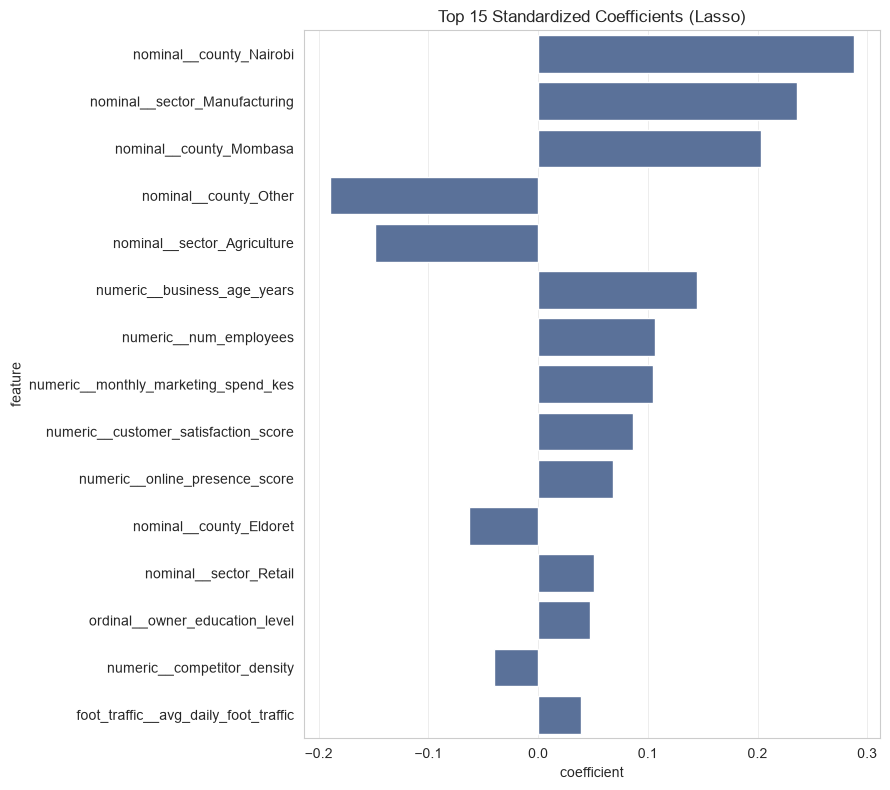

In [46]:
# Use the best tuned estimator from GridSearchCV
best_model = grid_search_linear.best_estimator_
best_regressor = best_model.named_steps["model"]
best_model_name = best_regressor.__class__.__name__

feature_names_out = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(best_regressor, "coef_"):
    # Linear family: coefficient-based explainability
    coefs_df = pd.DataFrame({
        "feature": feature_names_out,
        "coefficient": best_regressor.coef_
    }).sort_values("coefficient", key=abs, ascending=False)

    plt.figure(figsize=(9, 8))
    top_coefs = coefs_df.head(15)
    sns.barplot(data=top_coefs, y="feature", x="coefficient", color="#4F6EA4")
    plt.title(f"Top 15 Standardized Coefficients ({best_model_name})")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not provide .coef_.")
    print("Use permutation importance / SHAP / Partial Dependence Plots for explainability instead.")

### SHapley Additive exPlanations (SHAP) Values

SHAP is a method for explaining individual predictions of a machine learning
model. It answers the question: "For this specific prediction, how much did
each feature contribute, and in which direction?"

**Origin:** It is built on Shapley values, a concept from cooperative game
theory originally designed to fairly distribute a payout among players based
on their individual contribution to a team effort **(Shapley, 1952)**. SHAP
repurposes this idea: features are treated as "players," and the model's
prediction (relative to a baseline/average prediction) is the "payout" to be
distributed.

**Core idea:** For a given prediction, SHAP computes each feature's contribution
by considering all possible orderings in which features could be "added" to
the model, and averaging the marginal effect of that feature across all these
orderings. This ensures the contribution attributed to each feature is fair and
consistent, instead of being dependent on an arbitrary order.

**Key properties:**

- *Additive:* If you add up the SHAP values of every feature for a given
observation, the total equals exactly the difference between that
observation's prediction and the model's baseline (average) prediction.
No portion of the prediction is left unexplained.

- *Local:* SHAP produces a separate explanation for each individual observation,
rather than one explanation for the model as a whole. As a result, the same
feature can contribute differently to different observations, even though the
underlying model does not change.

- *Model-agnostic in principle:* SHAP can be applied to any model (linear
regression, random forests, gradient boosting, neural networks), although
model-specific implementations (e.g., TreeExplainer for tree-based models)
are faster than the generic version of SHAP.

**Expected output:**

- *Force plot / waterfall plot*: Shows one prediction. Start at the baseline
(average prediction), then see how each feature pushes it up or down, bar by
bar, until you reach the final predicted value.

- *Summary plot (beeswarm)*: Shows the whole dataset. Features are ranked top
to bottom by importance. Each dot is one observation. Its left/right position
shows whether that feature pushed the prediction down or up, and its color (red
= high value, blue = low value) shows whether high or low values of that feature
drive predictions up or down.

**Caveat:** **SHAP values explain what the model learned, not necessarily true
causal relationships in the real world**. This means that a feature with a
large SHAP value is influential to the model's output, not automatically the
"true cause" of the outcome.

Shapley, L. S. (1952). *A Value for N-Person Games.* RAND Corporation.
[https://doi.org/10.7249/P0295](https://doi.org/10.7249/P0295)

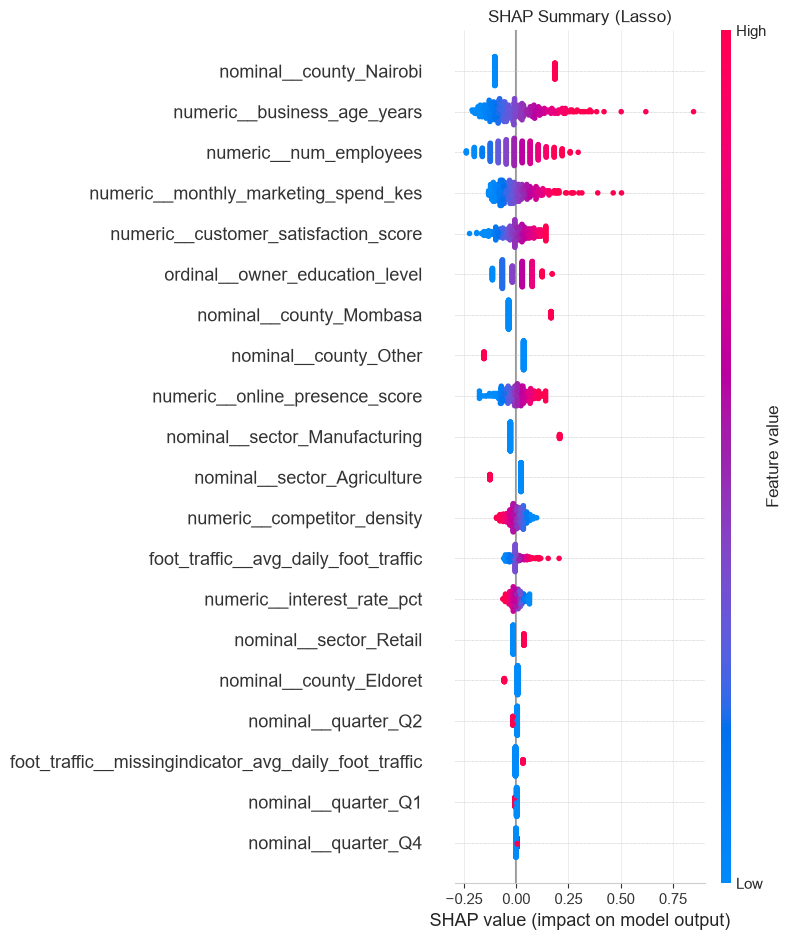

In [47]:
import shap

# 1) Best tuned pipeline/model
best_pipeline = grid_search_linear.best_estimator_
best_regressor = best_pipeline.named_steps["model"]
best_model_name = best_regressor.__class__.__name__

# 2) Data sample and transformed matrix
X_test_sample = X_test.iloc[:500].copy()
X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test_sample)
feature_names_out = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 3) SHAP by model type
if "Forest" in best_model_name or "GradientBoosting" in best_model_name or "Tree" in best_model_name:
    explainer = shap.TreeExplainer(best_regressor)
    shap_values = explainer.shap_values(X_test_transformed)

    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names_out,
        show=False
    )
    plt.title(f"SHAP Summary ({best_model_name})")
    plt.tight_layout()
    plt.show()

elif hasattr(best_regressor, "coef_"):
    # Explicit masker removes the max_samples warning
    masker = shap.maskers.Independent(X_test_transformed, max_samples=300)
    explainer = shap.LinearExplainer(best_regressor, masker=masker)
    shap_values = explainer(X_test_transformed)

    shap.summary_plot(
        shap_values.values,
        X_test_transformed,
        feature_names=feature_names_out,
        show=False
    )
    plt.title(f"SHAP Summary ({best_model_name})")
    plt.tight_layout()
    plt.show()

else:
    print(f"SHAP explainer not configured for model type: {best_model_name}")

### Partial Dependence Plots (PDP)

A PDP shows how a model's predicted output changes as one feature varies, while
averaging out the effect of all other features.

**How it works:** For a chosen feature, the algorithm takes every observation in
the dataset, artificially sets that feature to a fixed value, keeps all other
features unchanged, and averages the resulting predictions. This is repeated
across a range of values for the feature, producing a curve.

**What it shows:** The marginal, average effect of a feature on the prediction.
For example, "as customer tenure increases, predicted revenue tends to rise,
holding everything else constant."

The x-axis shows the feature's values; the y-axis shows the model's average
predicted output. The line's slope tells you the relationship: rising means
higher feature values push predictions up, falling means they push predictions
down, flat means the feature has little effect in that range.

Key differences from SHAP:

- PDP is global and averaged: one curve for the whole dataset, not
observation-specific.
- PDP does not decompose individual predictions the way SHAP does.
- PDP can be misleading when features are correlated, because "holding other
features constant" may create unrealistic combinations (e.g., varying house
size while holding the number of rooms fixed).

In [48]:
from sklearn.inspection import PartialDependenceDisplay

best_pipeline = grid_search_linear.best_estimator_
best_model_name = best_pipeline.named_steps["model"].__class__.__name__

features_to_plot = ["monthly_marketing_spend_kes", "online_presence_score"]

# PDP works best for tree/ensemble models
if "Forest" in best_model_name or "GradientBoosting" in best_model_name or "Tree" in best_model_name:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    PartialDependenceDisplay.from_estimator(
        best_pipeline,
        X_train_corr_vif_rfe_lasso,
        features=features_to_plot,
        ax=ax
    )
    plt.title(f"Partial Dependence ({best_model_name})")
    plt.tight_layout()
    plt.show()
else:
    print(f"PDP skipped: best model is {best_model_name}.")
    print("PDP is possible, but usually more informative for tree-based models.")

PDP skipped: best model is Lasso.
PDP is possible, but usually more informative for tree-based models.


We create a Partial Dependence Plot below for the GradientBoosting model.
This is forced so that we can see how a PDP plot looks like.

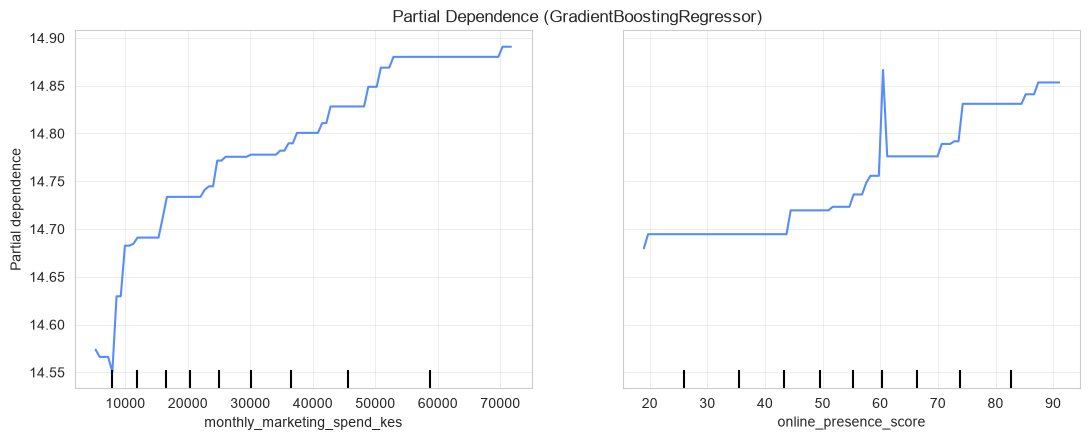

In [49]:
from sklearn.inspection import PartialDependenceDisplay
import pandas as pd

# Extract the best GradientBoosting configuration from the grid search results,
# regardless of which model was selected as best overall
cv_results_df = pd.DataFrame(grid_search_linear.cv_results_)
gb_mask = cv_results_df["param_model"].apply(
    # `lambda` is a "tiny inline function" used on each value in
    # cv_results_df["param_model"].
    # It does this for each m:
        # gets the class name: m.__class__.__name__
        # checks if it equals "GradientBoostingRegressor"
        # returns True or False
    lambda m: m.__class__.__name__ == "GradientBoostingRegressor"
)
gb_results = cv_results_df[gb_mask]
best_gb_idx = gb_results["mean_test_score"].idxmax()
best_gb_params = cv_results_df.loc[best_gb_idx, "params"]

# Rebuild and refit a pipeline using those best GradientBoosting parameters
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])
gb_pipeline.set_params(**best_gb_params)
gb_pipeline.fit(X_train_corr_vif_rfe_lasso, y_train_log)

# Plot PDP for GradientBoosting specifically
features_to_plot = ["monthly_marketing_spend_kes", "online_presence_score"]

fig, ax = plt.subplots(figsize=(11, 4.5))
plt.title("Partial Dependence (GradientBoostingRegressor)")
PartialDependenceDisplay.from_estimator(
    gb_pipeline,
    X_train_corr_vif_rfe_lasso,
    features=features_to_plot,
    ax=ax
)
plt.tight_layout()
plt.show()

### Permutation Feature Importance

**Core idea:** Shuffle one feature's values (breaking its relationship with the target) and see how much worse the model's predictions become. A larger drop in performance means the feature was more important.

**How it works:**

1. Record the model's baseline performance (e.g., RMSE) on the test/validation set.
2. Randomly shuffle one feature's column, leaving all other features and the target unchanged.
3. Re-score the model on this shuffled data.
4. The importance of that feature is the drop in performance (shuffled score minus baseline score).
5. Repeat for each feature.

**Interpretation:** A feature that causes a large performance drop when shuffled is important — the model relied on it. A feature that causes little or no drop was making an insignificant contribution, even if it was included in the model.

Key advantages:

- Model-agnostic: works for any model, not just tree-based ones.
- Reflects actual predictive contribution, not just a coefficient or split count.

**Caveat:** Like PDPs, this method can be misleading when features are correlated. Shuffling one correlated feature may not hurt performance much, because a similar feature is still available to the model. This can make truly important features appear artificially unimportant.

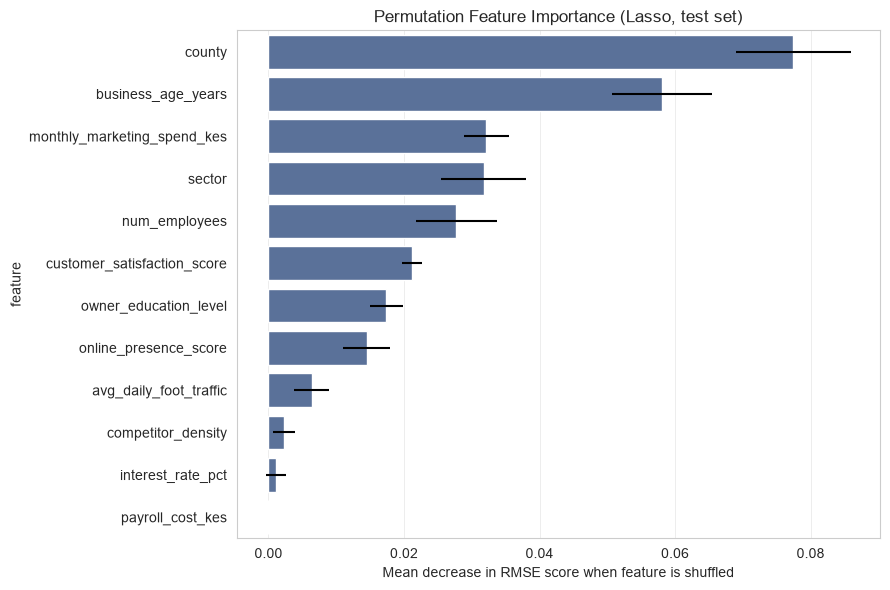

In [50]:
from sklearn.inspection import permutation_importance

best_pipeline = grid_search_linear.best_estimator_
best_model_name = best_pipeline.named_steps["model"].__class__.__name__

perm_result = permutation_importance(
    best_pipeline,
    X_test,
    y_test_log,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(9, 6))
top = perm_importance_df.head(12)
sns.barplot(
    data=top,
    y="feature",
    x="importance_mean",
    color="#4F6EA4",
    xerr=top["importance_std"]
)
plt.title(f"Permutation Feature Importance ({best_model_name}, test set)")
plt.xlabel("Mean decrease in RMSE score when feature is shuffled")
plt.tight_layout()
plt.show()

## Model Persistence

We persist the **entire fitted pipeline** ﷿﷿﷿ preprocessing and model together ﷿﷿﷿ as a single
object. Saving the model alone without its exact fitted preprocessing steps is a common
error: at inference time, new data would need to pass through the identical encoding,
imputation, and scaling logic that was fit on the training data, and saving them separately
risks a mismatch between training-time and inference-time transformations.

In [51]:
import joblib

# Automatically picks the best tuned pipeline from GridSearchCV
final_pipeline = grid_search_linear.best_estimator_

# (Optional) refit on full training data to be explicit; often already fit by GridSearchCV refit=True
final_pipeline.fit(X_train_corr_vif_rfe_lasso, y_train_log)

joblib.dump(final_pipeline, "sme_revenue_regression_pipeline.joblib")
print("Best pipeline saved to sme_revenue_regression_pipeline.joblib")
print("Selected model:", final_pipeline.named_steps["model"].__class__.__name__)

Best pipeline saved to sme_revenue_regression_pipeline.joblib
Selected model: Lasso


In [52]:
import joblib
import pandas as pd
import numpy as np

loaded_pipeline = joblib.load("sme_revenue_regression_pipeline.joblib")

# New sample (raw/original feature format expected by the pipeline)
new_business = pd.DataFrame([{
    "sector": "Technology",
    "county": "Nairobi",
    "quarter": "Q3",
    "business_age_years": 4.5,
    "num_employees": 12,
    "owner_education_level": "Bachelors",
    "monthly_marketing_spend_kes": 45000,
    "avg_daily_foot_traffic": np.nan,
    "online_presence_score": 78.0,
    "loan_amount_kes": 250000,
    "interest_rate_pct": 14.5,
    "inflation_rate_pct": 6.5,
    "competitor_density": 5,
    "customer_satisfaction_score": 4.2,
}])

# Optional: confirm expected input columns
expected_cols = loaded_pipeline.named_steps["preprocessor"].feature_names_in_
missing = set(expected_cols) - set(new_business.columns)
extra = set(new_business.columns) - set(expected_cols)
print("Missing columns:", missing)
print("Extra columns:", extra)

# Predict (model outputs log1p scale because target was trained as y_train_log)
pred_log = loaded_pipeline.predict(new_business)[0]
pred_kes = np.expm1(pred_log)

print(f"Predicted monthly revenue: {pred_kes:,.0f} KES")

Missing columns: set()
Extra columns: {'inflation_rate_pct', 'loan_amount_kes'}
Predicted monthly revenue: 4,552,657 KES


## Summary

This notebook walked through a complete regression workflow: exploratory analysis,
a leakage-safe train/test split, feature selection performed exclusively on training
data, a preprocessing pipeline handling encoding, structured and random missingness,
scaling, and skew correction, cross-validated comparison of seven regression models,
formal regression diagnostics, held-out evaluation, hyperparameter tuning, four
complementary explainability techniques, and persistence of the complete fitted pipeline.

**A note on ordering discipline**: every stage from Feature Selection onward operated on
`X_train` / `y_train` only, with the test set held out until the later stages. This ordering is not
a stylistic preference; reversing it silently invalidates every metric reported above.